# Layer Depth Analysis (1, 2, 3, 4 LSTM layers)

# Pre processing

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import RobustScaler
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence
from torch.optim.lr_scheduler import ReduceLROnPlateau

SEED = 42
DATA_PATH = Path("Merged_Dataset_yoy.csv")
PREDICTION_TARGETS = ["EBITDA", "Net_Income", "ROA"]
DEFAULT_LOOKBACK_DAYS = 365

MAX_EPOCHS = 200
PATIENCE = MAX_EPOCHS
TEST_YEAR_CUTOFF = 2023
N_SPLITS = 5
N_RUNS = 20
SYMLOG_CAP = float(np.log1p(3.0))

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(max(1, torch.get_num_threads() // 2))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Data Processing

In [ ]:
def load_and_prepare_yoy_data(data_path: Path, lookback_days: int = 365):
    try:
        df = pd.read_csv(data_path)
    except FileNotFoundError:
        df = pd.read_csv("Merged_Dataset_yoy.csv")

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values(["Company", "Date"]).reset_index(drop=True)
    df["year"] = df["Date"].dt.year

    df["Close_logret"] = df.groupby("Company")["Close"].transform(lambda x: np.log(x / x.shift(1)))
    df["Volume_log"] = np.log1p(df["Volume"].clip(lower=0))

    df["has_targets"] = df[PREDICTION_TARGETS].notna().any(axis=1)
    year_end_records = df[df["has_targets"]].copy()
    prior_static_cols = [
        "Prior_EBITDA_SL", "Prior_NI_SL", "Prior_ROA",
        "Leverage", "Cash_Ratio", "Size_SL",
        "Prior_Net_Sales_SL", "Prior_OpEx_SL", "Prior_FCF_Per_Share_SL",
    ]
    current_year_cols = [
        "Total_Assets", "Total_Debt", "Cash",
        "Net_Sales", "Operating_Expenses", "FCF_Per_Share",
    ]
    static_cols = ["MC_MIB", "MC_MID", "MC_SMALL", "Sector"]
    exclude_cols = ({"Date", "Company", "year", "has_targets"}
                    | set(PREDICTION_TARGETS) | set(prior_static_cols)
                    | set(current_year_cols) | set(static_cols))
    feature_cols = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

    sequences = []
    for company in df["Company"].unique():
        company_records = year_end_records[year_end_records["Company"] == company].copy()
        company_data = df[df["Company"] == company].copy()

        for _, year_end_row in company_records.iterrows():
            year = int(year_end_row["year"])
            year_end_date = year_end_row["Date"]

            prior_year_records = year_end_records[
                (year_end_records["Company"] == company) & (year_end_records["year"] == year - 1)
            ]
            if prior_year_records.empty:
                continue

            prior_row = prior_year_records.iloc[0]
            window_start = year_end_date - pd.Timedelta(days=lookback_days)
            window = company_data[(company_data["Date"] > window_start) & (company_data["Date"] <= year_end_date)].copy()

            if len(window) < 200:
                continue

            window[feature_cols] = window[feature_cols].ffill().bfill()
            if window[feature_cols].isna().any().any():
                continue

            static_cols = ["MC_MIB", "MC_MID", "MC_SMALL",
                           "Prior_EBITDA_SL", "Prior_NI_SL", "Prior_ROA",
                           "Leverage", "Cash_Ratio", "Size_SL",
                           "Prior_Net_Sales_SL", "Prior_OpEx_SL", "Prior_FCF_Per_Share_SL"]
            static_data = window[static_cols].iloc[-1].to_numpy(dtype=np.float32)
            sector_str = str(window["Sector"].iloc[-1])

            sequences.append({
                "company": company, "year": year, "year_end_date": year_end_date,
                "window_data": window[feature_cols].to_numpy(dtype=np.float32),
                "static_data": static_data,
                "sector": sector_str,
                **{f"current_{t.lower()}": year_end_row[t] for t in PREDICTION_TARGETS},
                **{f"prior_{t.lower()}": prior_row[t] for t in PREDICTION_TARGETS},
            })

    data_records = []
    for seq in sequences:
        for target_name in PREDICTION_TARGETS:
            current_val = seq[f"current_{target_name.lower()}"]
            prior_val = seq[f"prior_{target_name.lower()}"]
            if pd.isna(current_val) or pd.isna(prior_val):
                continue

            label_value = (current_val - prior_val) / (np.abs(prior_val) + 1e-8)

            data_records.append({
                "company": seq["company"], "year": seq["year"], "year_end_date": seq["year_end_date"],
                "target": target_name, "label_value": label_value,
                "window_data": seq["window_data"],
                "static_data": seq["static_data"],
                "sector": seq["sector"],
            })

    return pd.DataFrame(data_records), feature_cols

data_df, feature_cols = load_and_prepare_yoy_data(DATA_PATH, lookback_days=DEFAULT_LOOKBACK_DAYS)

def temporal_kfold_split(df: pd.DataFrame, n_splits: int = N_SPLITS, test_year_cutoff: int = TEST_YEAR_CUTOFF):
    if df.empty:
        raise ValueError("The dataset is empty. Check if DEFAULT_LOOKBACK_DAYS is too small.")

    available_years = sorted(int(y) for y in df["year"].unique())
    pre_test_years = [y for y in available_years if y <= test_year_cutoff]
    print(f"Available years in dataset: {available_years}")

    if len(pre_test_years) < n_splits + 1:
        raise ValueError(f"Not enough pre-test years ({len(pre_test_years)}) for {n_splits} folds (need >= {n_splits+1}).")

    val_years = pre_test_years[-n_splits:]
    test_set = df[df["year"] > test_year_cutoff].copy()
    print(f"Test: > {test_year_cutoff} ({len(test_set)} samples)")
    print(f"Temporal k-fold ({n_splits} folds, expanding window). Val years: {val_years}")

    folds = []
    for fold_idx, vy in enumerate(val_years, start=1):
        train_set = df[df["year"] < vy].copy()
        val_set = df[df["year"] == vy].copy()
        if train_set.empty or val_set.empty:
            print(f"WARNING: fold {fold_idx} (val {vy}) has empty train ({len(train_set)}) or val ({len(val_set)}). Skipping.")
            continue
        folds.append((train_set, val_set, vy, fold_idx))
        print(f"  Fold {fold_idx}: train <= {vy-1} ({len(train_set)}), val = {vy} ({len(val_set)})")

    if not folds:
        raise ValueError("No valid folds produced.")
    return folds, test_set

def split_to_single(df: pd.DataFrame, test_year_cutoff: int = TEST_YEAR_CUTOFF):
    folds, test_set = temporal_kfold_split(df, n_splits=1, test_year_cutoff=test_year_cutoff)
    train_set, val_set, _, _ = folds[-1]
    return train_set, val_set, test_set

def make_robust_scaler(train_df: pd.DataFrame, feature_indices):
    sc = RobustScaler()
    train_windows = np.vstack([row[:, feature_indices] for row in train_df["window_data"]])
    sc.fit(train_windows)
    return sc

## Pipeline Setup (Symlog, RobustScaler, Packing)

In [ ]:
SELECTED_FEATURES = [
    'Close_logret', 'Volume_log',
    'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'Euribor_3M', 'FTMIB_Volume',
    'GVZ_Close', 'IT_Inflation', 'Brent_Close', 'OVX_Close', 'TTF_Gas_Close',
    'VIX_Close', 'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv',
    'PCOPPUSDM', 'PALUMUSDM', 'NFCI', 'ff_HML', 'ff_Mom',
    'FTMIB_Close', 'IT10YT_Yield', 'IT_Unemployment', 'Brent_Volume'
]
STATIC_FEATURES = ['MC_MIB', 'MC_MID', 'MC_SMALL']
STATIC_DIM = len(STATIC_FEATURES)
selected_indices = [feature_cols.index(f) for f in SELECTED_FEATURES]
print(f"Selected temporal features ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}")
print(f"Static features ({len(STATIC_FEATURES)}): {STATIC_FEATURES}")

# SYMLOG TRANSFORMATION
idx_value = data_df["target"].isin(PREDICTION_TARGETS)
y_val = data_df.loc[idx_value, "label_value"]
data_df.loc[idx_value, "label_value"] = np.sign(y_val) * np.log1p(np.abs(y_val))

# Single-split for final-test path
train_data, val_data, test_data = split_to_single(data_df, test_year_cutoff=TEST_YEAR_CUTOFF)
robust_scaler = make_robust_scaler(train_data, selected_indices) if not train_data.empty else RobustScaler()
print("Success: RobustScaler fitted correctly on single-split train.")

Selected temporal features (26): ['Close_logret', 'Volume_log', 'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'Euribor_3M', 'FTMIB_Volume', 'GVZ_Close', 'IT_Inflation', 'Brent_Close', 'OVX_Close', 'TTF_Gas_Close', 'VIX_Close', 'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv', 'PCOPPUSDM', 'PALUMUSDM', 'NFCI', 'ff_HML', 'ff_Mom', 'FTMIB_Close', 'IT10YT_Yield', 'IT_Unemployment', 'Brent_Volume']
Static features (3): ['MC_MIB', 'MC_MID', 'MC_SMALL']
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Test: > 2023 (1028 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (5174), val = 2023 (513)
Success: RobustScaler fitted correctly on single-split train.


## Model Definitions

In [ ]:
class ShallowLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_targets: int = 1,
                 dropout: float = 0.0, static_dim: int = 0):
        super().__init__()
        self.static_dim = static_dim
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size + static_dim, num_targets)

    def forward(self, x, lengths, static=None):
        packed_x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        _, (hn, _) = self.lstm(packed_x)
        hidden = self.dropout(hn[-1])
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = self.head(hidden)
        if logits.size(-1) == 1:
            logits = logits.squeeze(-1)
        return logits

In [ ]:
CONFIG = {
    "hidden_size": 128,
    "batch_size": 32,
    "lr": 1e-3,
    "dropout": 0.0,
    "weight_decay": 0.0,
}

## Helpers: MTL Dataset, Collate, Evaluation

In [ ]:
def extract_mtl_df(df: pd.DataFrame) -> pd.DataFrame:
    mtl_records = []
    for (company, year), group in df.groupby(["company", "year"]):
        window_data = group.iloc[0]["window_data"]
        year_end_date = group.iloc[0]["year_end_date"]
        static_data = group.iloc[0]["static_data"]
        label_value = np.full(len(PREDICTION_TARGETS), np.nan, dtype=np.float32)
        for i, t in enumerate(PREDICTION_TARGETS):
            t_row = group[group["target"] == t]
            if not t_row.empty:
                label_value[i] = t_row.iloc[0]["label_value"]
        mtl_records.append({
            "company": company, "year": year, "year_end_date": year_end_date,
            "window_data": window_data, "static_data": static_data,
            "sector": group.iloc[0]["sector"] if "sector" in group.iloc[0].index else "",
            "label_value": label_value
        })
    return pd.DataFrame(mtl_records)

class YoYDatasetMTL(Dataset):
    def __init__(self, data_df, scaler, feature_indices, window_size=None):
        self.data_df = data_df.reset_index(drop=True)
        self.scaler = scaler
        self.feature_indices = feature_indices
        self.window_size = window_size

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        row = self.data_df.iloc[idx]
        window = row["window_data"][:, self.feature_indices].copy()
        if self.window_size is not None:
            window = window[-self.window_size:]
        if self.scaler:
            window = self.scaler.transform(window)
        static = row["static_data"].astype(np.float32)
        target = row["label_value"]
        mask = ~np.isnan(target)
        target_clean = np.nan_to_num(target, nan=0.0)
        return (
            torch.from_numpy(window),
            torch.from_numpy(static),
            torch.tensor(target_clean, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.bool),
            len(window),
        )

def collate_fn_mtl(batch):
    batch.sort(key=lambda x: x[4], reverse=True)
    sequences = [x[0] for x in batch]
    statics = torch.stack([x[1] for x in batch])
    targets = torch.stack([x[2] for x in batch])
    masks = torch.stack([x[3] for x in batch])
    lengths = torch.tensor([x[4] for x in batch])
    padded_seqs = torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True)
    return padded_seqs, targets, masks, statics, lengths

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

def evaluate_loader(model, loader):
    model.eval()
    all_preds, all_targets, all_masks = [], [], []
    with torch.no_grad():
        for bx, by, bmask, bstatic, lengths in loader:
            logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
            all_preds.append(logits.cpu().numpy())
            all_targets.append(by.numpy())
            all_masks.append(bmask.numpy())
    if not all_preds:
        return None
    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_targets)
    y_pred = np.clip(y_pred, -SYMLOG_CAP, SYMLOG_CAP)
    y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
    y_true = np.sign(y_true) * np.expm1(np.abs(y_true))
    mask = np.vstack(all_masks)
    res = {}
    all_errors = []
    for i, t in enumerate(PREDICTION_TARGETS):
        m = mask[:, i]
        if m.sum() == 0:
            continue
        res[t] = np.mean(np.abs(y_pred[m, i] - y_true[m, i]))
        all_errors.extend(np.abs(y_pred[m, i] - y_true[m, i]).tolist())
    res["Overall"] = np.mean(all_errors) if all_errors else None
    return res

In [ ]:
mib_tickers = [
    "A2A", "AMPLIFON", "AZIMUT", "BANCA MEDIOLANUM", "BANCA MONTE DEI PASCHI",
    "BANCA PPO.DI SONDRIO", "BANCO BPM", "BPER BANCA", "BRUNELLO CUCINELLI",
    "BUZZI", "DAVIDE CAMPARI MILANO", "DIASORIN", "ENEL", "ENI",
    "FERRARI (MIL)", "FINCANTIERI", "FINECOBANK", "GENERALI", "HERA",
    "INFRASTRUTTURE WIRELESS ITALIANE NPV", "INTESANPAOLO", "ITALGAS",
    "IVECO", "LEONARDO", "LOTTOMATICA", "MEDIOBANCA BC.FIN", "MONCLER",
    "NEXI", "POSTE ITALIANE", "PRYSMIAN", "RECORDATI INDUA.CHIMICA",
    "SAIPEM", "SNAM", "STELLANTIS", "STMICROELECTRONICS (MIL)",
    "TELECOM ITALIA", "TENARIS", "TERNA RETE ELETTRICA NAZ", "UNICREDIT",
    "UNIPOL ASSICURAZIONI"
]

mid_tickers = [
    "ACEA", "ALERION CLEAN POWER", "ANIMA", "ARISTON",
    "ARNOLDO MONDADORI EDI.", "ASCOPIAVE", "AVIO", "BANCA GENERALI",
    "BANCA IFIS", "BFF BANK", "BNC.DI DESIO E DELB.", "CALTAGIRONE",
    "CAREL", "CEMBRE", "CEMENTIR", "COMPAGNIE INDUSTRIALI RIUNITE SHS",
    "CREDITO EMILIANO", "D'AMICO INTL.SHIP.", "DANIELI", "DATALOGIC",
    "DE LONGHI", "EL EN", "ENAV", "ERG", "FERRETTI (MIL)",
    "FIERA MILANO", "FRENI BREMBO", "GVS", "INTERCOS", "INTERPUMP",
    "IREN", "ITALMOBILIARE", "JUVENTUS FOOTBALL CLUB", "LUVE", "MARIE",
    "MARR", "MFE B", "MFE-MEDIAFOREUROPE", "MOLTIPLY", "NEWPRINCES",
    "OVS", "PHARMANUTRA", "PHILOGEN", "PIRELLI & C", "RAI WAY",
    "REPLY", "RIZZOLI CRER.DLSM.GP.", "SAFILO", "SALVATORE FERRAGAMO",
    "SANLORENZO", "SESA", "SOL", "TECHNOGYM", "TECHNOPROBE", "TINEXTA",
    "WEBUILD", "WIIT", "ZIGNAGO VETRO"
]

small_tickers = [
    "ABITARE IN", "AEDES", "AEFFE", "AEROP GUGL MARCO",
    "ALTEA GREEN POWER", "ANTARES VISION", "AQUAFIL", "B&C SPEAKERS",
    "BANCA PROFILO", "BANCA SISTEMA", "BASICNET", "BASTOGI", "BEEWIZE",
    "BIESSE", "BORGOSESIA", "BRIOSCHI SVILUPPO IMMBL", "CAIRO COMMUNICATION",
    "CALEFFI", "CALTAGIRONE EDITORE", "CELLULARLINE",
    "CENTRALE DEL LATTE D'ITALIA", "CLASS EDITORI", "CSP INTERNATIONAL",
    "CY4GATE", "DIGITAL BROS", "DIGITAL VALUE", "DOVALUE", "ELICA", "EMAK",
    "ENERVIT", "EPRICE", "EQUITA", "ESPRINET", "EUROGROUP LAMINATIONS A",
    "EUROTECH", "FIDIA", "FILA", "FNM", "GABETTI PROPERTY SLTN.",
    "GAROFALO HEALTH CARE", "GAS PLUS", "GEFRAN", "GENERALFINANCE",
    "GEOX", "GPI", "GRANDI VIAGGI", "IMMOBILIARE GRDE. DTBZ. SO.DI INVM.IMMB.",
    "IMMSI", "INDEL B", "INDUSTRIE DE NORA", "IRCE", "IT WAY",
    "ITALIAN DESIGN BRAND", "ITALIAN EXHIBITION", "ITALIAN SEA",
    "LANDI RENZO", "MET EXTRA", "MONDO TV", "NEODECORTECH", "OLIDATA",
    "OPS ITALIA", "OPS RETAIL", "ORSERO", "PININFARINA", "PIQUADRO",
    "PLC", "RATTI", "REVO INSURANCE", "RISANAMENTO", "SABAF", "SECO",
    "SERI INDUSTRIAL", "SIT", "SOFTLAB", "SOGEFI", "SOMEC", "SS LAZIO",
    "SYS-DAT", "TESMEC", "TESSELLIS", "TREVI FIN INDUSTRIALE", "TRIBOO",
    "TXT E-SOLUTION", "UNIDATA", "VALSOIA", "VINCENZO ZUCCHI", "ZEST"
]

ticker_groups = {"MIB": mib_tickers, "Mid-cap": mid_tickers, "Small-cap": small_tickers}

## Improved Pipeline (Fundamentals + Prior Targets + Winsor ±3)

Static features now combine the 3 MC dummies with the 9 prior-year
fundamental columns precomputed upstream in Merged_Dataset_yoy.csv:
symlog(prior EBITDA / Net_Income / Net_Sales / Operating_Expenses /
FCF_Per_Share), prior ROA, leverage, cash ratio, and firm size. Samples
whose prior-year fundamentals are missing (NaN in the static vector) are
dropped here. Winsorizes the YoY ratio at ±3 before symlog. This gives the
model the strongest possible signal so it can overfit when regularization
is removed.

In [ ]:
WINSOR_CAP = 3.0
SECTOR_LIST = sorted(data_df["sector"].unique())
SECTOR_TO_IDX = {s: i for i, s in enumerate(SECTOR_LIST)}
N_SECTORS = len(SECTOR_LIST)
print(f"Sectors ({N_SECTORS}): {SECTOR_LIST}")

def sector_onehot(sector_str):
    v = np.zeros(N_SECTORS, dtype=np.float32)
    if sector_str in SECTOR_TO_IDX:
        v[SECTOR_TO_IDX[sector_str]] = 1.0
    return v

def build_full_static(static_data_arr, sector_str):
    mc_and_prior = np.asarray(static_data_arr, dtype=np.float32)  # 12 dims (3 MC + 9 Prior_*)
    sector_oh = sector_onehot(sector_str)                          # 11 dims
    return np.concatenate([mc_and_prior[:3], sector_oh, mc_and_prior[3:]]).astype(np.float32)

static_nan_mask = data_df["static_data"].apply(
    lambda a: bool(np.isnan(np.asarray(a, dtype=float)).any())
)
data_df_imp_base = data_df.loc[~static_nan_mask].copy().reset_index(drop=True)
data_df_imp_base["static_data"] = data_df_imp_base.apply(
    lambda r: build_full_static(r["static_data"], r["sector"]), axis=1
)

n_drop_missing = len(data_df) - len(data_df_imp_base)
print(f"Dropped {n_drop_missing} samples missing prior-year fundamentals; "
      f"{len(data_df_imp_base)} remaining.")

data_df_imp = data_df_imp_base.copy()

sym_lab = data_df_imp["label_value"].to_numpy()
raw_ratio = np.sign(sym_lab) * np.expm1(np.abs(sym_lab))
capped = np.clip(raw_ratio, -WINSOR_CAP, WINSOR_CAP)
data_df_imp["label_value"] = (np.sign(capped) * np.log1p(np.abs(capped))).astype(np.float32)
n_capped = int(np.sum(np.abs(raw_ratio) > WINSOR_CAP))
print(f"Robust symlog label: capped {n_capped}/{len(raw_ratio)} "
      f"({100.0*n_capped/len(raw_ratio):.2f}%) at +/-{int(WINSOR_CAP)}.")

STATIC_DIM_IMP = 3 + N_SECTORS + 9   # MC(3) + sector(N_SECTORS) + Prior_*(9) = 23
NEW_STATIC_SLICE = slice(3 + N_SECTORS, 3 + N_SECTORS + 9)   # scale only Prior_*, passthrough MC + sector
print(f"STATIC_DIM_IMP={STATIC_DIM_IMP} (MC=3, sector={N_SECTORS}, prior=9)")
print(f"NEW_STATIC_SLICE = {NEW_STATIC_SLICE.start}:{NEW_STATIC_SLICE.stop} (only prior gets RobustScaler)")

train_data_imp, val_data_imp, test_data_imp = split_to_single(data_df_imp, test_year_cutoff=TEST_YEAR_CUTOFF)
mtl_train_imp_raw = extract_mtl_df(train_data_imp)
mtl_val_imp_raw   = extract_mtl_df(val_data_imp)
mtl_test_imp      = extract_mtl_df(test_data_imp)

def fit_static_scaler(mtl_df, new_slice=NEW_STATIC_SLICE):
    arr = np.vstack(mtl_df["static_data"].values).astype(np.float32)
    return RobustScaler().fit(arr[:, new_slice])

def apply_static_scaler(mtl_df, sc, new_slice=NEW_STATIC_SLICE):
    df = mtl_df.copy().reset_index(drop=True)
    arr = np.vstack(df["static_data"].values).astype(np.float32)
    arr[:, new_slice] = sc.transform(arr[:, new_slice]).astype(np.float32)
    df["static_data"] = [arr[i] for i in range(len(arr))]
    return df

def build_loaders_imp(params):
    temp_sc = make_robust_scaler(mtl_train_imp_raw, selected_indices)
    stat_sc = fit_static_scaler(mtl_train_imp_raw)
    train_ds = YoYDatasetMTL(apply_static_scaler(mtl_train_imp_raw, stat_sc), temp_sc, selected_indices)
    val_ds   = YoYDatasetMTL(apply_static_scaler(mtl_val_imp_raw,   stat_sc), temp_sc, selected_indices)
    test_ds  = YoYDatasetMTL(apply_static_scaler(mtl_test_imp,      stat_sc), temp_sc, selected_indices)
    train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True,  collate_fn=collate_fn_mtl)
    val_loader   = DataLoader(val_ds,   batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)
    test_loader  = DataLoader(test_ds,  batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)
    model = ShallowLSTM(len(selected_indices), params["hidden_size"], len(PREDICTION_TARGETS),
                        params.get("dropout", 0.0), static_dim=STATIC_DIM_IMP).to(DEVICE)
    return model, train_loader, val_loader, test_loader

# --- Per-year test loaders for 2024/2025 breakdown ---
mtl_test_2024 = mtl_test_imp[mtl_test_imp["year"] == 2024].reset_index(drop=True)
mtl_test_2025 = mtl_test_imp[mtl_test_imp["year"] == 2025].reset_index(drop=True)
print(f"Per-year test split: 2024={len(mtl_test_2024)} samples, 2025={len(mtl_test_2025)} samples")

def make_imp_test_loader_for_year(year, params):
    year_df = mtl_test_imp[mtl_test_imp["year"] == year].reset_index(drop=True)
    temp_sc = make_robust_scaler(mtl_train_imp_raw, selected_indices)
    stat_sc = fit_static_scaler(mtl_train_imp_raw)
    test_ds = YoYDatasetMTL(apply_static_scaler(year_df, stat_sc), temp_sc, selected_indices)
    return DataLoader(test_ds, batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)


Sectors (10): ['Basic Materials', 'Consumer Cyclicals', 'Consumer Non-Cyclicals', 'Energy', 'Financials', 'Healthcare', 'Industrials', 'Real Estate', 'Technology', 'Utilities']
Dropped 970 samples missing prior-year fundamentals; 5745 remaining.
Robust symlog label: capped 493/5745 (8.58%) at +/-3.
STATIC_DIM_IMP=22 (MC=3, sector=10, prior=9)
NEW_STATIC_SLICE = 13:22 (only prior gets RobustScaler)
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Test: > 2023 (919 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (4367), val = 2023 (459)
Per-year test split: 2024=157 samples, 2025=150 samples


## Weight Initialization & Diagnostics Utilities

- **Xavier uniform** on all LSTM weights (PyTorch default, made explicit).
- **Zero bias** on LSTM (forget gate starts at sigmoid(0) = 0.5).
- **Small normal head** (std=1e-3) + zero bias so initial output ≈ 0 ("no change" prior).

Per-epoch tracking: weight norm, grad norm (last-batch sample), and
‖W_t − W_{t−1}‖ (delta norm — integrates all batch updates in the epoch).

In [ ]:
def init_model_weights(model, head_std=1e-3):
    for name, param in model.lstm.named_parameters():
        if 'weight' in name:
            nn.init.xavier_uniform_(param)
        elif 'bias' in name:
            nn.init.zeros_(param)
    nn.init.normal_(model.head.weight, mean=0.0, std=head_std)
    nn.init.zeros_(model.head.bias)

def snapshot_weight_stats(model):
    stats = {}
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        t = param.detach()
        stats[name] = {
            "norm": float(t.norm().item()),
            "std":  float(t.std().item()) if t.numel() > 1 else 0.0,
            "mean": float(t.mean().item()),
            "min":  float(t.min().item()),
            "max":  float(t.max().item()),
        }
    return stats

def snapshot_grad_stats(model):
    stats = {}
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        g = param.grad
        if g is None:
            stats[name] = {"norm": None, "std": None, "mean": None, "min": None, "max": None}
        else:
            g = g.detach()
            stats[name] = {
                "norm": float(g.norm().item()),
                "std":  float(g.std().item()) if g.numel() > 1 else 0.0,
                "mean": float(g.mean().item()),
                "min":  float(g.min().item()),
                "max":  float(g.max().item()),
            }
    return stats

def compute_delta_stats(prev_state, curr_state):
    deltas = {}
    for name in curr_state:
        if name in prev_state:
            d = curr_state[name].detach() - prev_state[name].detach()
            deltas[name] = {"norm": float(d.norm().item())}
        else:
            deltas[name] = {"norm": None}
    return deltas

def log_initial_weights(model):
    print(f"{'Parameter':<40} {'Shape':<20} {'Norm':>10} {'Std':>10} {'Mean':>10} {'Min':>10} {'Max':>10}")
    print("-" * 110)
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        t = param.detach()
        shape_str = str(list(t.shape))
        print(f"{name:<40} {shape_str:<20} {t.norm().item():10.4f} "
              f"{(t.std().item() if t.numel() > 1 else 0.0):10.4f} {t.mean().item():10.4f} "
              f"{t.min().item():10.4f} {t.max().item():10.4f}")

In [ ]:
def train_with_diagnostics(model, train_loader, val_loader, optimizer,
                           grad_clip=5.0, use_scheduler=False, scheduler_patience=20,
                           max_epochs=None, verbose=True):
    criterion = nn.L1Loss(reduction='none')
    max_epochs = max_epochs or MAX_EPOCHS
    scheduler = (ReduceLROnPlateau(optimizer, mode='min', patience=scheduler_patience, factor=0.5)
                 if use_scheduler else None)

    history = {
        "train_loss": [], "val_loss": [], "train_mae": [], "val_mae": [],
        "weight_stats": [], "grad_stats": [], "delta_stats": [], "lr": [],
    }

    prev_state = {name: t.detach().cpu().clone() for name, t in model.state_dict().items()}
    history["weight_stats"].append(snapshot_weight_stats(model))
    history["grad_stats"].append({name: {"norm": None} for name, _ in model.named_parameters()})
    history["delta_stats"].append({name: {"norm": None} for name, _ in model.named_parameters()})

    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_loss_sum, epoch_loss_count = 0.0, 0
        for bx, by, bmask, bstatic, lengths in train_loader:
            bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(bx, lengths, bstatic)
            loss_m = criterion(logits, by)
            mask_f = bmask.to(loss_m.dtype)
            loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)
            epoch_loss_sum += loss_m[bmask].sum().item() if bmask.any() else 0.0
            epoch_loss_count += int(bmask.sum().item())
            if loss.requires_grad:
                loss.backward()
                if grad_clip is not None and grad_clip > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
                optimizer.step()
        history["train_loss"].append(epoch_loss_sum / max(epoch_loss_count, 1))

        last_grad_stats = snapshot_grad_stats(model)

        curr_state = {name: t.detach().cpu().clone() for name, t in model.state_dict().items()}
        delta_stats = compute_delta_stats(prev_state, curr_state)
        prev_state = curr_state

        history["weight_stats"].append(snapshot_weight_stats(model))
        history["grad_stats"].append(last_grad_stats)
        history["delta_stats"].append(delta_stats)
        history["lr"].append(optimizer.param_groups[0]['lr'])

        model.eval()
        def compute_mae(loader):
            P, T, M = [], [], []
            with torch.no_grad():
                for bx, by, bmask, bstatic, lengths in loader:
                    logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
                    P.append(logits.cpu().numpy()); T.append(by.numpy()); M.append(bmask.numpy())
            yp = np.vstack(P); yt = np.vstack(T); m = np.vstack(M).astype(bool)
            yp_c = np.clip(yp, -SYMLOG_CAP, SYMLOG_CAP)
            yp_c = np.sign(yp_c) * np.expm1(np.abs(yp_c))
            yt_c = np.sign(yt) * np.expm1(np.abs(yt))
            ae = np.abs(yp_c - yt_c)
            return np.mean(ae[m]) if m.any() else 0.0

        def compute_loss(loader):
            tot, cnt = 0.0, 0
            with torch.no_grad():
                for bx, by, bmask, bstatic, lengths in loader:
                    bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                    logits = model(bx, lengths, bstatic)
                    lm = criterion(logits, by)
                    mb = bmask.bool()
                    if mb.any():
                        tot += lm[mb].sum().item(); cnt += int(mb.sum().item())
            return tot / max(cnt, 1) if cnt > 0 else None

        tr_mae = compute_mae(train_loader)
        va_mae = compute_mae(val_loader)
        va_loss = compute_loss(val_loader)
        history["train_mae"].append(tr_mae)
        history["val_mae"].append(va_mae)
        history["val_loss"].append(va_loss)

        if scheduler is not None:
            scheduler.step(va_mae)

        if verbose and (epoch % 5 == 0 or epoch == 1 or epoch == max_epochs):
            print(f"Epoch {epoch:3d}/{max_epochs} | train_loss={history['train_loss'][-1]:.4f} "
                  f"val_loss={va_loss:.4f} | train_mae={tr_mae:.4f} val_mae={va_mae:.4f} "
                  f"| lr={optimizer.param_groups[0]['lr']:.2e}")

    return model, history

# Training

In [ ]:
CONFIG = {
    "hidden_size": 128,
    "batch_size": 32,
    "lr": 1e-3,
    "dropout": 0.0,
    "weight_decay": 0.0,
}

In [ ]:
DEPTHS = [1, 2, 3, 4]
N_RUNS_DEPTH = 5

def _to_jsonable(o):
    if isinstance(o, (np.floating,)):
        return float(o)
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, torch.Tensor):
        return o.detach().cpu().tolist()
    raise TypeError(f"Not JSON serializable: {type(o)}")

def save_json(path, obj):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w') as f:
        _json.dump(obj, f, default=_to_jsonable)

def load_json(path):
    with open(path) as f:
        return _json.load(f)

class StackedLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_layers: int = 1,
                 num_targets: int = 1, dropout: float = 0.0, static_dim: int = 0):
        super().__init__()
        self.static_dim = static_dim
        self.num_layers = num_layers
        # inter-layer dropout is fixed at 0.0 to keep the no-regularization setting
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=0.0)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size + static_dim, num_targets)

    def forward(self, x, lengths, static=None):
        packed_x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        _, (hn, _) = self.lstm(packed_x)
        hidden = self.dropout(hn[-1])
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = self.head(hidden)
        if logits.size(-1) == 1:
            logits = logits.squeeze(-1)
        return logits

def build_loaders_imp_depth(params, num_layers):
    temp_sc = make_robust_scaler(mtl_train_imp_raw, selected_indices)
    stat_sc = fit_static_scaler(mtl_train_imp_raw)
    train_ds = YoYDatasetMTL(apply_static_scaler(mtl_train_imp_raw, stat_sc), temp_sc, selected_indices)
    val_ds   = YoYDatasetMTL(apply_static_scaler(mtl_val_imp_raw,   stat_sc), temp_sc, selected_indices)
    test_ds  = YoYDatasetMTL(apply_static_scaler(mtl_test_imp,      stat_sc), temp_sc, selected_indices)
    train_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True,  collate_fn=collate_fn_mtl)
    val_loader   = DataLoader(val_ds,   batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_mtl)
    test_loader  = DataLoader(test_ds,  batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_mtl)
    model = StackedLSTM(len(selected_indices), params['hidden_size'],
                        num_layers=num_layers, num_targets=len(PREDICTION_TARGETS),
                        dropout=params.get('dropout', 0.0), static_dim=STATIC_DIM_IMP).to(DEVICE)
    return model, train_loader, val_loader, test_loader

def count_lstm_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Per-year test loaders are deterministic given the data and batch_size, so build them once
test_loader_2024_ref = make_imp_test_loader_for_year(2024, CONFIG)
test_loader_2025_ref = make_imp_test_loader_for_year(2025, CONFIG)
print(f"Reference test loaders ready: 2024={len(test_loader_2024_ref.dataset)} samples, "
      f"2025={len(test_loader_2025_ref.dataset)} samples")


SAVE_DIR = /content/sweep_results
Reference test loaders ready: 2024=157 samples, 2025=150 samples


In [ ]:
def train_with_diagnostics(model, train_loader, val_loader, optimizer,
                           grad_clip=5.0, use_scheduler=False, scheduler_patience=20,
                           max_epochs=None, verbose=True):
    criterion = nn.L1Loss(reduction='none')
    max_epochs = max_epochs or MAX_EPOCHS
    scheduler = (ReduceLROnPlateau(optimizer, mode='min', patience=scheduler_patience, factor=0.5)
                 if use_scheduler else None)

    history = {
        "train_loss": [], "val_loss": [], "train_mae": [], "val_mae": [],
        "weight_stats": [], "grad_stats": [], "delta_stats": [], "lr": [],
    }

    prev_state = {name: t.detach().cpu().clone() for name, t in model.state_dict().items()}
    history["weight_stats"].append(snapshot_weight_stats(model))
    history["grad_stats"].append({name: {"norm": None} for name, _ in model.named_parameters()})
    history["delta_stats"].append({name: {"norm": None} for name, _ in model.named_parameters()})

    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_loss_sum, epoch_loss_count = 0.0, 0
        for bx, by, bmask, bstatic, lengths in train_loader:
            bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(bx, lengths, bstatic)
            loss_m = criterion(logits, by)
            mask_f = bmask.to(loss_m.dtype)
            loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)
            epoch_loss_sum += loss_m[bmask].sum().item() if bmask.any() else 0.0
            epoch_loss_count += int(bmask.sum().item())
            if loss.requires_grad:
                loss.backward()
                if grad_clip is not None and grad_clip > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
                optimizer.step()
        history["train_loss"].append(epoch_loss_sum / max(epoch_loss_count, 1))

        last_grad_stats = snapshot_grad_stats(model)

        curr_state = {name: t.detach().cpu().clone() for name, t in model.state_dict().items()}
        delta_stats = compute_delta_stats(prev_state, curr_state)
        prev_state = curr_state

        history["weight_stats"].append(snapshot_weight_stats(model))
        history["grad_stats"].append(last_grad_stats)
        history["delta_stats"].append(delta_stats)
        history["lr"].append(optimizer.param_groups[0]['lr'])

        model.eval()
        def compute_mae(loader):
            P, T, M = [], [], []
            with torch.no_grad():
                for bx, by, bmask, bstatic, lengths in loader:
                    logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
                    P.append(logits.cpu().numpy()); T.append(by.numpy()); M.append(bmask.numpy())
            yp = np.vstack(P); yt = np.vstack(T); m = np.vstack(M).astype(bool)
            yp_c = np.clip(yp, -SYMLOG_CAP, SYMLOG_CAP)
            yp_c = np.sign(yp_c) * np.expm1(np.abs(yp_c))
            yt_c = np.sign(yt) * np.expm1(np.abs(yt))
            ae = np.abs(yp_c - yt_c)
            return np.mean(ae[m]) if m.any() else 0.0

        def compute_loss(loader):
            tot, cnt = 0.0, 0
            with torch.no_grad():
                for bx, by, bmask, bstatic, lengths in loader:
                    bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                    logits = model(bx, lengths, bstatic)
                    lm = criterion(logits, by)
                    mb = bmask.bool()
                    if mb.any():
                        tot += lm[mb].sum().item(); cnt += int(mb.sum().item())
            return tot / max(cnt, 1) if cnt > 0 else None

        tr_mae = compute_mae(train_loader)
        va_mae = compute_mae(val_loader)
        va_loss = compute_loss(val_loader)
        history["train_mae"].append(tr_mae)
        history["val_mae"].append(va_mae)
        history["val_loss"].append(va_loss)

        if scheduler is not None:
            scheduler.step(va_mae)

        if verbose and (epoch % 5 == 0 or epoch == 1 or epoch == max_epochs):
            print(f"Epoch {epoch:3d}/{max_epochs} | train_loss={history['train_loss'][-1]:.4f} "
                  f"val_loss={va_loss:.4f} | train_mae={tr_mae:.4f} val_mae={va_mae:.4f} "
                  f"| lr={optimizer.param_groups[0]['lr']:.2e}")

    return model, history

def overfit_single_batch(model, train_loader, optimizer, n_steps=200, grad_clip=5.0, verbose=True):
    criterion = nn.L1Loss(reduction='none')
    batch = next(iter(train_loader))
    bx, by, bmask, bstatic, lengths = batch
    bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)

    losses = []
    model.train()
    for step in range(1, n_steps + 1):
        optimizer.zero_grad(set_to_none=True)
        logits = model(bx, lengths, bstatic)
        loss_m = criterion(logits, by)
        mask_f = bmask.to(loss_m.dtype)
        loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)
        if loss.requires_grad:
            loss.backward()
            if grad_clip is not None and grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            optimizer.step()
        losses.append(loss.item())
        if verbose and (step % 10 == 0 or step == 1 or step == n_steps):
            print(f"Step {step:3d}/{n_steps} | loss={loss.item():.6f}")
    return losses

## 1. Single-Batch Overfit by Depth

[capacity L=1] loaded from disk (final loss = 0.0517)
[capacity L=2] loaded from disk (final loss = 0.0355)
[capacity L=3] loaded from disk (final loss = 0.0830)
[capacity L=4] loaded from disk (final loss = 0.0635)


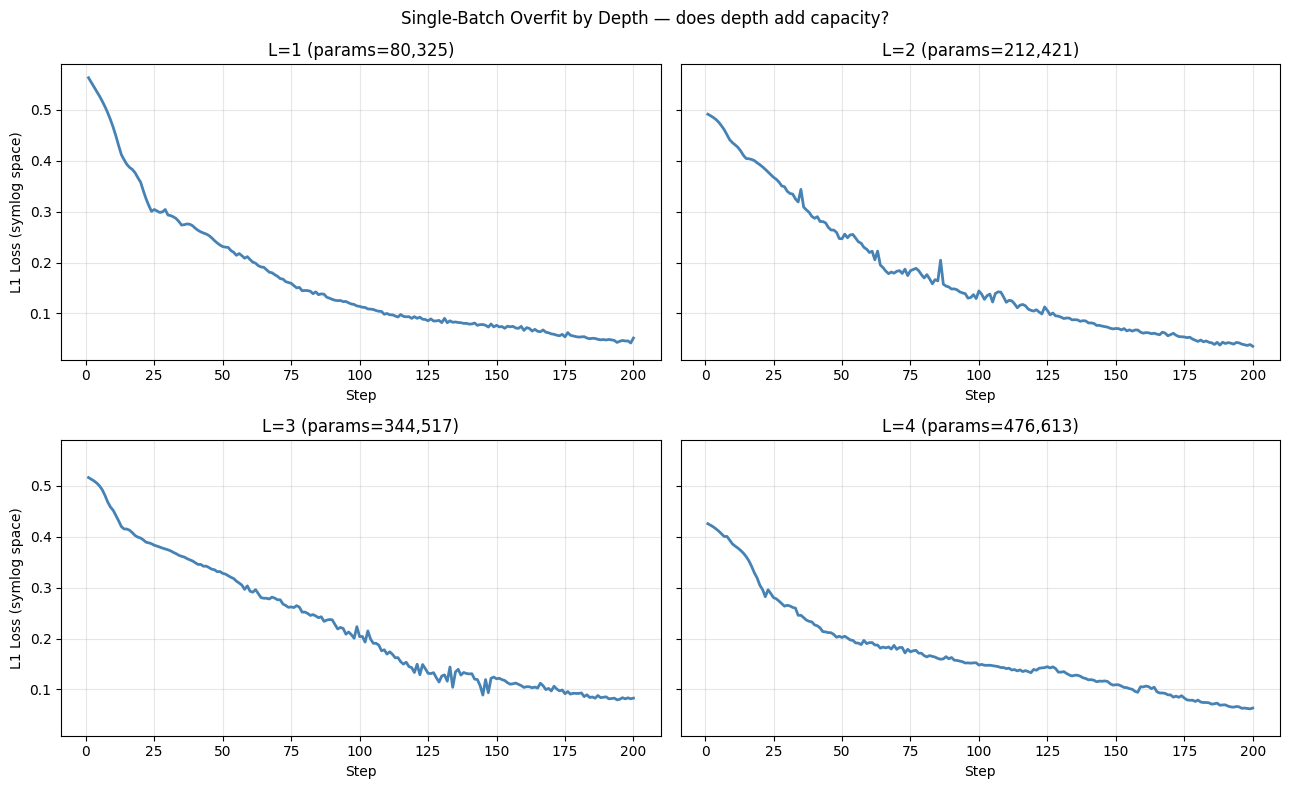


Capacity summary (final single-batch loss after 200 steps):
  L=1: params=80,325, final loss = 0.0517
  L=2: params=212,421, final loss = 0.0355
  L=3: params=344,517, final loss = 0.0830
  L=4: params=476,613, final loss = 0.0635


In [ ]:
capacity_results = {}
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
axes = axes.flatten()
for ax, L in zip(axes, DEPTHS):
    cap_path = SAVE_DIR / f'capacity_L{L}.json'
    if cap_path.exists():
        cap = load_json(cap_path)
        losses = cap['losses']
        n_params = cap['n_params']
        print(f"[capacity L={L}] loaded from disk (final loss = {losses[-1]:.4f})")
    else:
        set_seed(SEED)
        model_cap, train_loader_cap, _, _ = build_loaders_imp_depth(CONFIG, L)
        init_model_weights(model_cap)
        n_params = count_lstm_params(model_cap)
        opt_cap = torch.optim.Adam(model_cap.parameters(), lr=CONFIG['lr'], weight_decay=0.0)
        losses = overfit_single_batch(model_cap, train_loader_cap, opt_cap,
                                     n_steps=200, grad_clip=5.0, verbose=False)
        save_json(cap_path, {'depth': L, 'n_params': n_params, 'losses': losses})
        print(f"[capacity L={L}] n_params={n_params:,}, final loss = {losses[-1]:.4f}")
    capacity_results[L] = {'losses': losses, 'n_params': n_params}
    ax.plot(range(1, len(losses)+1), losses, linewidth=2, color='steelblue')
    ax.set_title(f"L={L} (params={n_params:,})")
    ax.set_xlabel("Step"); ax.grid(True, alpha=0.3)
    if L in (1, 3):
        ax.set_ylabel("L1 Loss (symlog space)")
fig.suptitle("Single-Batch by Depth")
plt.tight_layout()
plt.savefig(SAVE_DIR / 'capacity_overfit.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nCapacity summary (final single-batch loss after 200 steps):")
for L in DEPTHS:
    print(f"  L={L}: params={capacity_results[L]['n_params']:,}, final loss = {capacity_results[L]['losses'][-1]:.4f}")


## 2. Full Training per Depth 200 Epochs

[full training L=1] n_params=80,325, best val MAE = 0.6284 @ epoch 11, final val MAE = 0.9910
[full training L=2] n_params=212,421, best val MAE = 0.6277 @ epoch 30, final val MAE = 0.6994
[full training L=3] n_params=344,517, best val MAE = 0.6277 @ epoch 15, final val MAE = 0.7832
[full training L=4] n_params=476,613, best val MAE = 0.6265 @ epoch 29, final val MAE = 0.6686


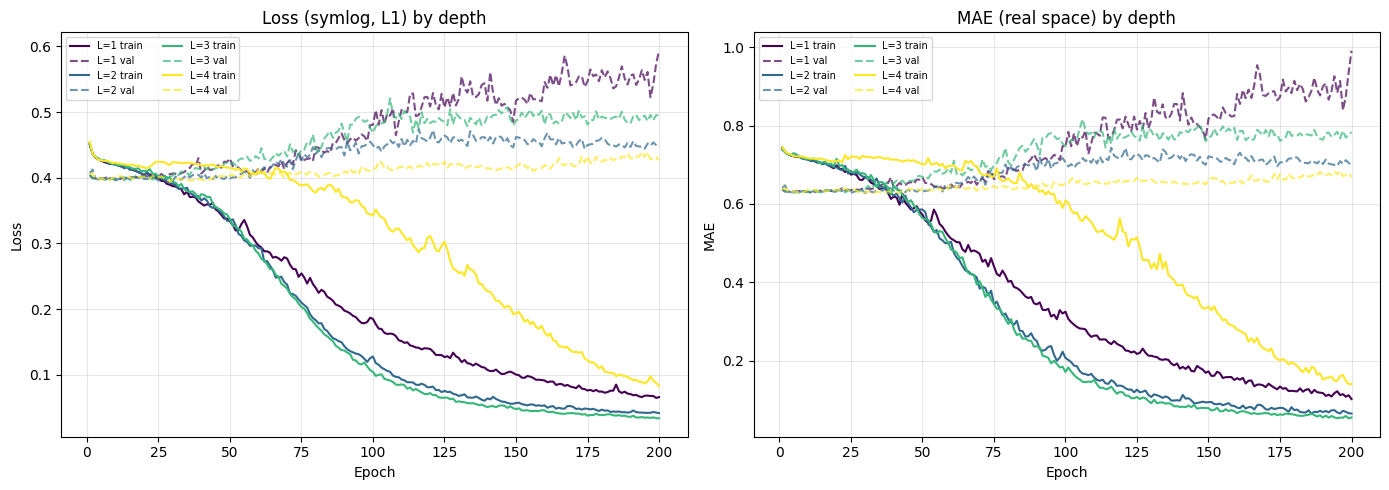


Full-training best-val summary (1 run per depth):
  L=1: params=80,325, best val MAE = 0.6284 @ epoch 11, final val = 0.9910
  L=2: params=212,421, best val MAE = 0.6277 @ epoch 30, final val = 0.6994
  L=3: params=344,517, best val MAE = 0.6277 @ epoch 15, final val = 0.7832
  L=4: params=476,613, best val MAE = 0.6265 @ epoch 29, final val = 0.6686


In [ ]:
depth_histories = {}
for L in DEPTHS:
    hist_path = SAVE_DIR / f'history_L{L}.json'
    if hist_path.exists():
        hist = load_json(hist_path)
        print(f"[full training L={L}] loaded from disk "
              f"(best val MAE = {hist['best_val_mae']:.4f} @ epoch {hist['best_val_epoch']}, "
              f"final val = {hist['val_mae'][-1]:.4f})")
    else:
        set_seed(SEED)
        model, train_loader, val_loader, _ = build_loaders_imp_depth(CONFIG, L)
        init_model_weights(model)
        n_params = count_lstm_params(model)
        opt = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'], weight_decay=0.0)
        model, h = train_with_diagnostics(
            model, train_loader, val_loader, opt,
            grad_clip=5.0, use_scheduler=False, max_epochs=MAX_EPOCHS, verbose=False
        )
        best_val_mae = float(min(h['val_mae']))
        best_val_epoch = int(np.argmin(h['val_mae'])) + 1
        hist = {
            'depth': L, 'n_params': n_params,
            'train_loss': [float(x) for x in h['train_loss']],
            'val_loss':   [float(x) for x in h['val_loss']],
            'train_mae':  [float(x) for x in h['train_mae']],
            'val_mae':    [float(x) for x in h['val_mae']],
            'lr':         [float(x) for x in h['lr']],
            'best_val_mae': best_val_mae,
            'best_val_epoch': best_val_epoch,
        }
        save_json(hist_path, hist)
        print(f"[full training L={L}] n_params={n_params:,}, best val MAE = {best_val_mae:.4f} "
              f"@ epoch {best_val_epoch}, final val MAE = {h['val_mae'][-1]:.4f}")
    depth_histories[L] = hist

# Overlay train/val loss and MAE for all 4 depths
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(DEPTHS)))
for color, L in zip(colors, DEPTHS):
    h = depth_histories[L]
    epochs_h = range(1, len(h['train_loss']) + 1)
    ax[0].plot(epochs_h, h['train_loss'], color=color, label=f"L={L} train", linewidth=1.5, linestyle='-')
    ax[0].plot(epochs_h, h['val_loss'],   color=color, label=f"L={L} val",   linewidth=1.5, linestyle='--', alpha=0.7)
    ax[1].plot(epochs_h, h['train_mae'],  color=color, label=f"L={L} train", linewidth=1.5, linestyle='-')
    ax[1].plot(epochs_h, h['val_mae'],    color=color, label=f"L={L} val",   linewidth=1.5, linestyle='--', alpha=0.7)
ax[0].set_title("Loss (symlog, L1)"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss")
ax[0].legend(fontsize=7, ncol=2); ax[0].grid(True, alpha=0.3)
ax[1].set_title("MAE (real space)"); ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("MAE")
ax[1].legend(fontsize=7, ncol=2); ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'full_training_depths.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nFull-training best-val summary (1 run per depth):")
for L in DEPTHS:
    h = depth_histories[L]
    print(f"  L={L}: params={h['n_params']:,}, best val MAE = {h['best_val_mae']:.4f} "
          f"@ epoch {h['best_val_epoch']}, final val = {h['val_mae'][-1]:.4f}")


## 3. Untrained vs Trained by Depth - 5 Seed

In [ ]:
depth_compare = {L: {
    'trained':        {t: [] for t in PREDICTION_TARGETS + ['Overall']},
    'untrained':      {t: [] for t in PREDICTION_TARGETS + ['Overall']},
    'trained_2024':   {t: [] for t in PREDICTION_TARGETS + ['Overall']},
    'trained_2025':   {t: [] for t in PREDICTION_TARGETS + ['Overall']},
    'untrained_2024': {t: [] for t in PREDICTION_TARGETS + ['Overall']},
    'untrained_2025': {t: [] for t in PREDICTION_TARGETS + ['Overall']},
} for L in DEPTHS}

for L in DEPTHS:
    print(f"\n=== Depth L={L} ({N_RUNS_DEPTH} seeds) ===")
    for run_idx in range(N_RUNS_DEPTH):
        per_run_path = SAVE_DIR / f'per_run_L{L}_seed{run_idx}.json'
        if per_run_path.exists():
            d = load_json(per_run_path)
            print(f"  [seed {run_idx} (SEED+{run_idx}={d['seed']})] loaded from disk")
        else:
            seed = SEED + run_idx
            set_seed(seed)
            model_u, _, _, test_loader = build_loaders_imp_depth(CONFIG, L)
            res_u    = evaluate_loader(model_u, test_loader)
            res_u_24 = evaluate_loader(model_u, test_loader_2024_ref)
            res_u_25 = evaluate_loader(model_u, test_loader_2025_ref)
            set_seed(seed)
            model_t, train_loader, val_loader, test_loader = build_loaders_imp_depth(CONFIG, L)
            opt = torch.optim.Adam(model_t.parameters(), lr=CONFIG['lr'], weight_decay=0.0)
            _, _ = train_with_diagnostics(
                model_t, train_loader, val_loader, opt,
                grad_clip=5.0, use_scheduler=False,
                max_epochs=MAX_EPOCHS, verbose=False
            )
            res_t    = evaluate_loader(model_t, test_loader)
            res_t_24 = evaluate_loader(model_t, test_loader_2024_ref)
            res_t_25 = evaluate_loader(model_t, test_loader_2025_ref)
            d = {
                'depth': L, 'seed': seed,
                'untrained':    res_u,    'trained':    res_t,
                'untrained_2024': res_u_24, 'trained_2024': res_t_24,
                'untrained_2025': res_u_25, 'trained_2025': res_t_25,
            }
            save_json(per_run_path, d)
            print(f"  [seed {run_idx} (SEED+{run_idx}={seed})] "
                  f"trained MAE overall = {res_t['Overall']:.4f}, "
                  f"untrained = {res_u['Overall']:.4f}")
        for k, v in d['untrained'].items():
            depth_compare[L]['untrained'][k].append(v)
        for k, v in d['trained'].items():
            depth_compare[L]['trained'][k].append(v)
        for k, v in d['untrained_2024'].items():
            depth_compare[L]['untrained_2024'][k].append(v)
        for k, v in d['trained_2024'].items():
            depth_compare[L]['trained_2024'][k].append(v)
        for k, v in d['untrained_2025'].items():
            depth_compare[L]['untrained_2025'][k].append(v)
        for k, v in d['trained_2025'].items():
            depth_compare[L]['trained_2025'][k].append(v)



=== Depth L=1 (5 seeds) ===
  [seed 0 (SEED+0=42)] trained MAE overall = 0.7274, untrained = 0.6268
  [seed 1 (SEED+1=43)] trained MAE overall = 0.8891, untrained = 0.6491
  [seed 2 (SEED+2=44)] trained MAE overall = 0.8327, untrained = 0.6281
  [seed 3 (SEED+3=45)] trained MAE overall = 1.1411, untrained = 0.6113
  [seed 4 (SEED+4=46)] trained MAE overall = 0.7995, untrained = 0.6437

=== Depth L=2 (5 seeds) ===
  [seed 0 (SEED+0=42)] trained MAE overall = 0.7040, untrained = 0.6235
  [seed 1 (SEED+1=43)] trained MAE overall = 0.6514, untrained = 0.6222
  [seed 2 (SEED+2=44)] trained MAE overall = 0.7117, untrained = 0.6425
  [seed 3 (SEED+3=45)] trained MAE overall = 0.7970, untrained = 0.6148
  [seed 4 (SEED+4=46)] trained MAE overall = 0.6773, untrained = 0.6305

=== Depth L=3 (5 seeds) ===
  [seed 0 (SEED+0=42)] trained MAE overall = 0.7130, untrained = 0.6273
  [seed 1 (SEED+1=43)] trained MAE overall = 0.6609, untrained = 0.6258
  [seed 2 (SEED+2=44)] trained MAE overall = 0.67

[L=1 seed=0] computed (n_test=307)


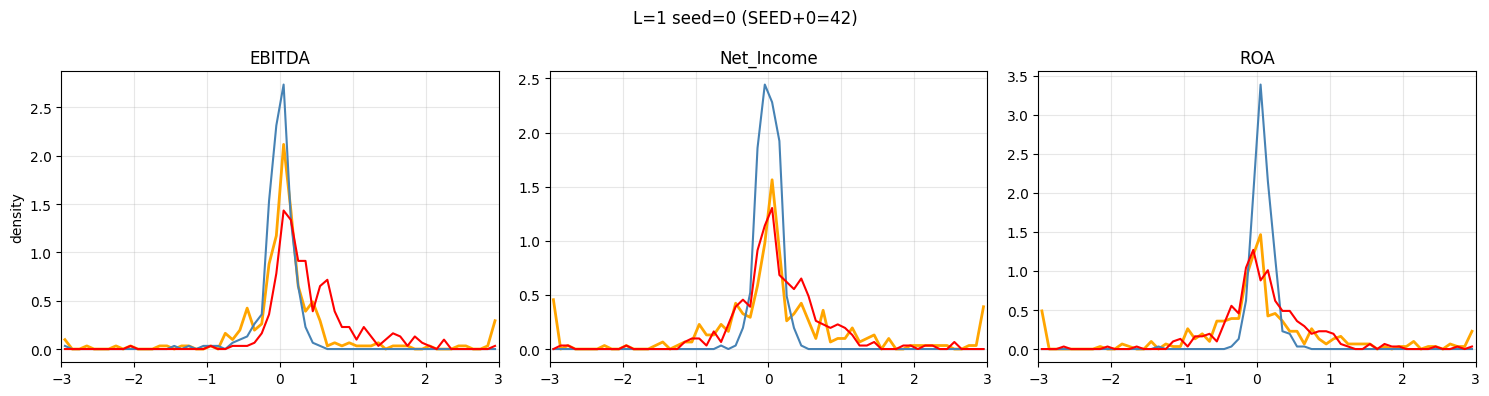

[L=1 seed=1] computed (n_test=307)


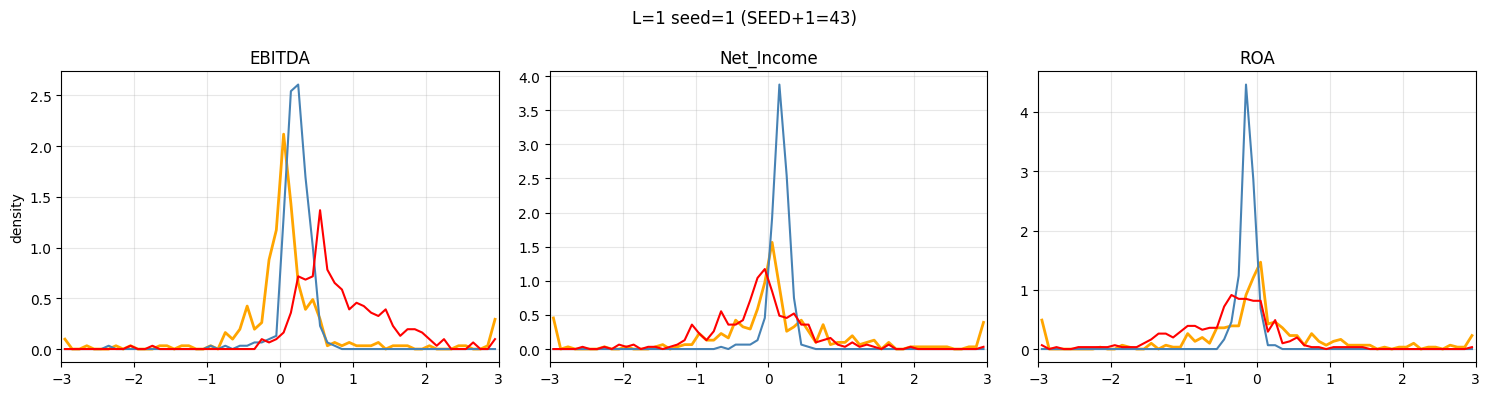

[L=1 seed=2] computed (n_test=307)


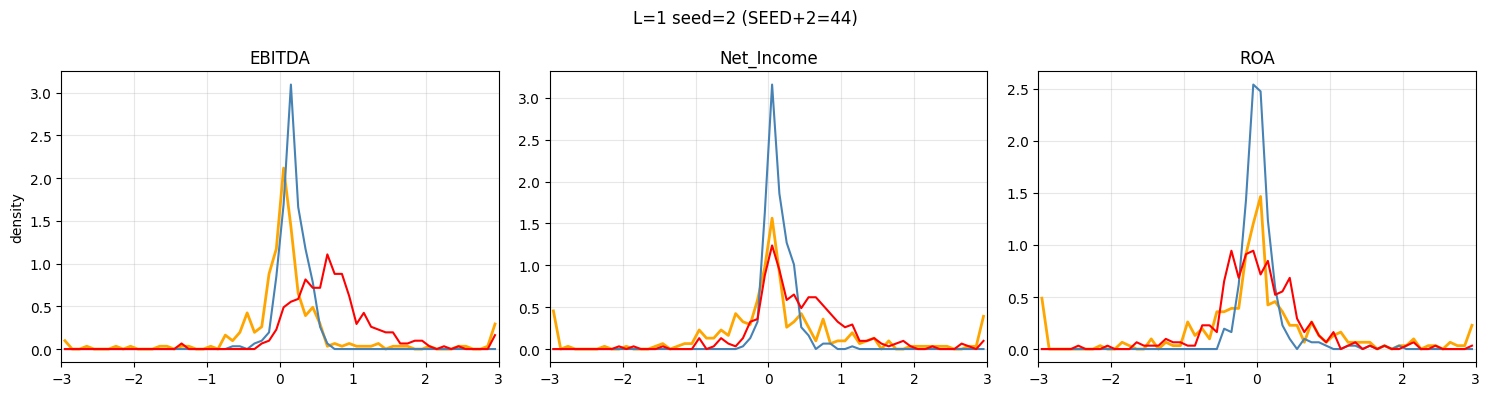

[L=1 seed=3] computed (n_test=307)


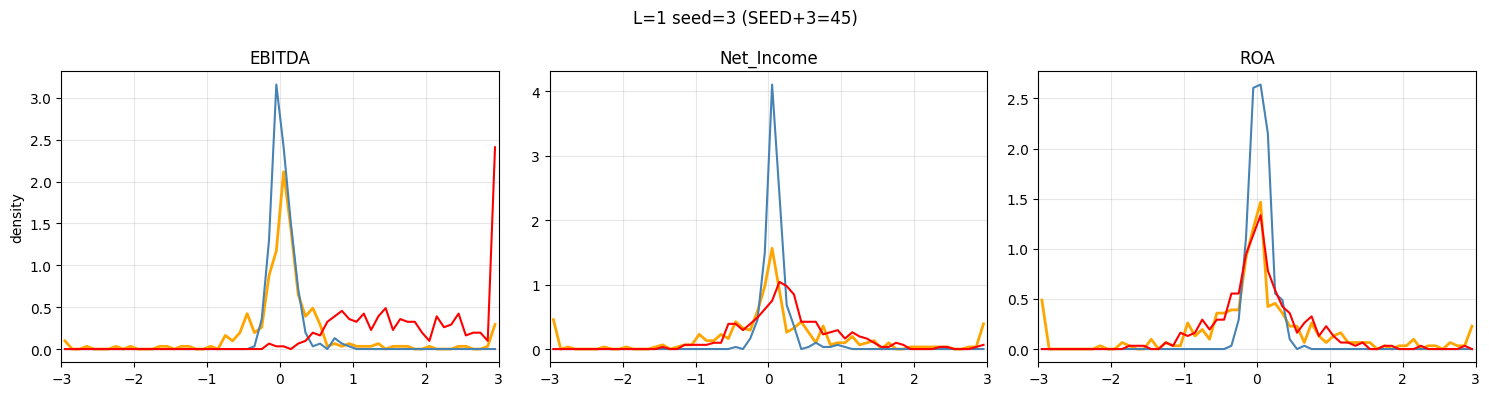

[L=1 seed=4] computed (n_test=307)


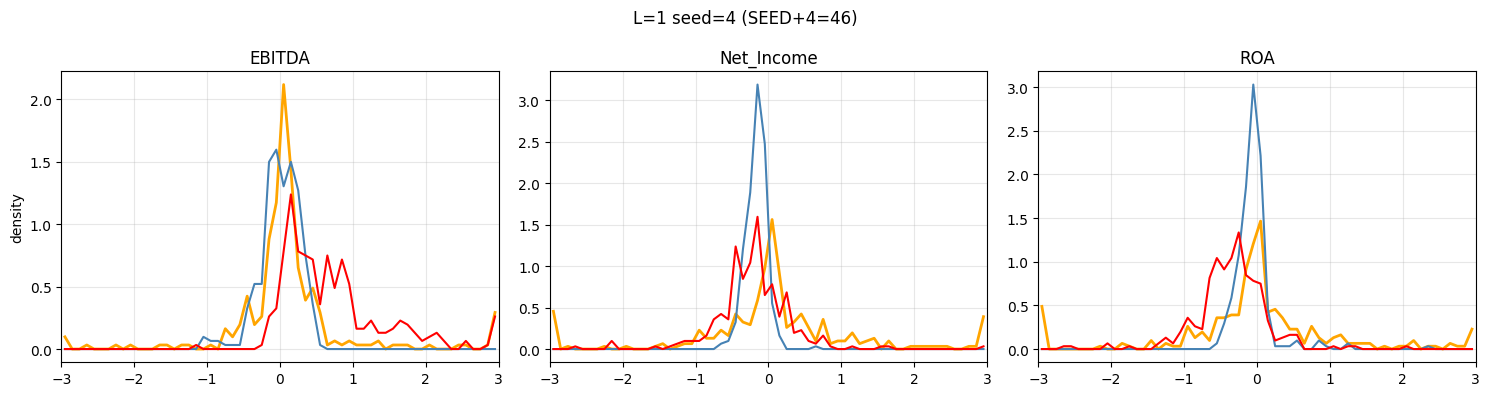

[L=2 seed=0] computed (n_test=307)


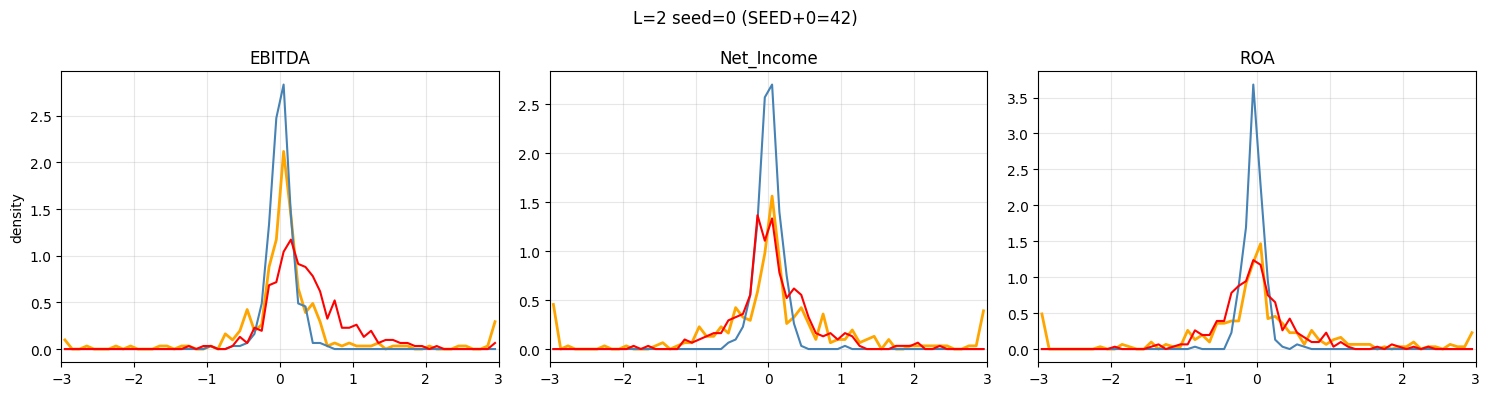

[L=2 seed=1] computed (n_test=307)


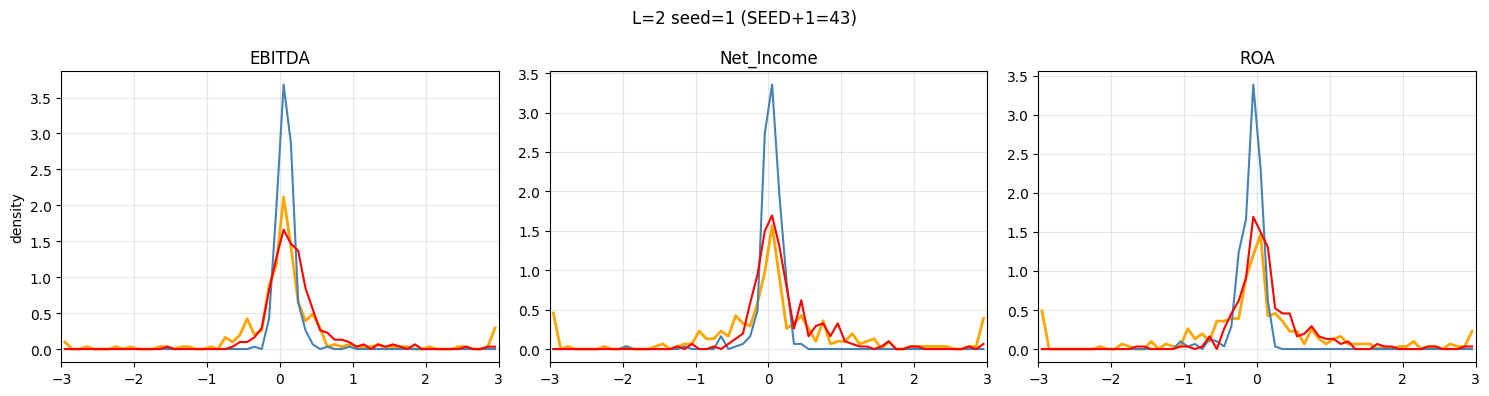

[L=2 seed=2] computed (n_test=307)


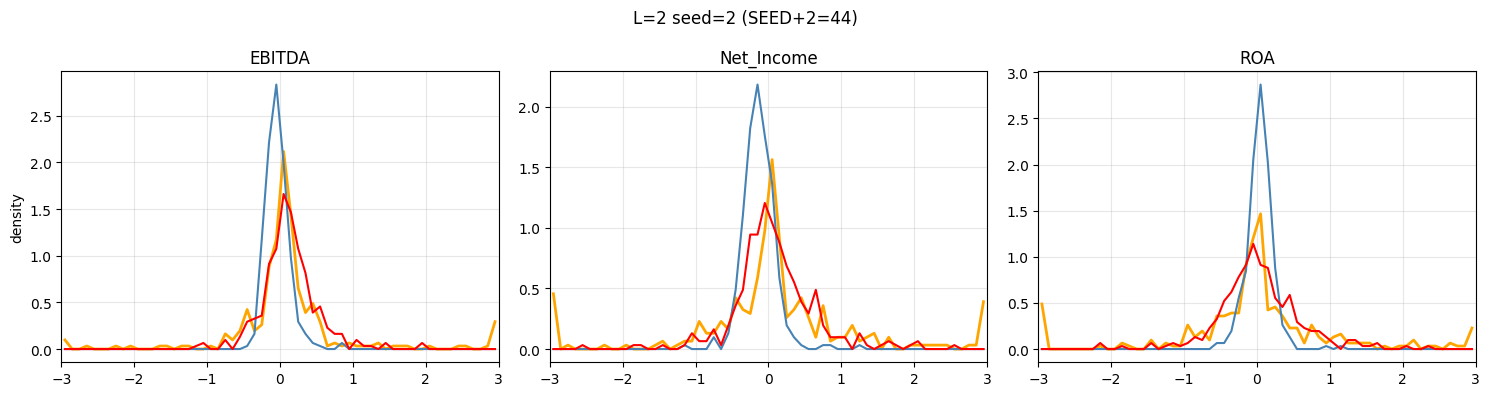

[L=2 seed=3] computed (n_test=307)


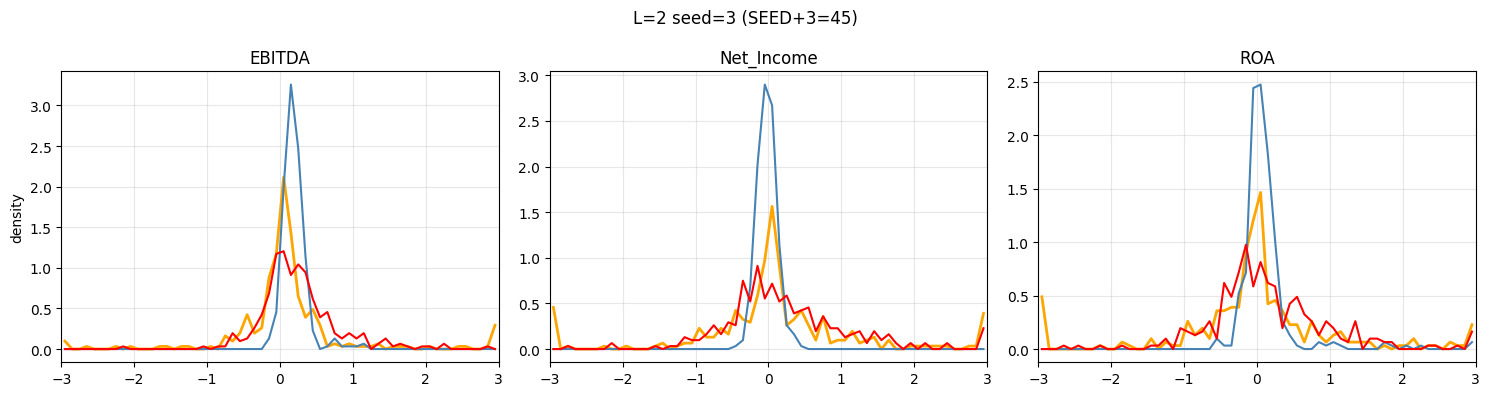

[L=2 seed=4] computed (n_test=307)


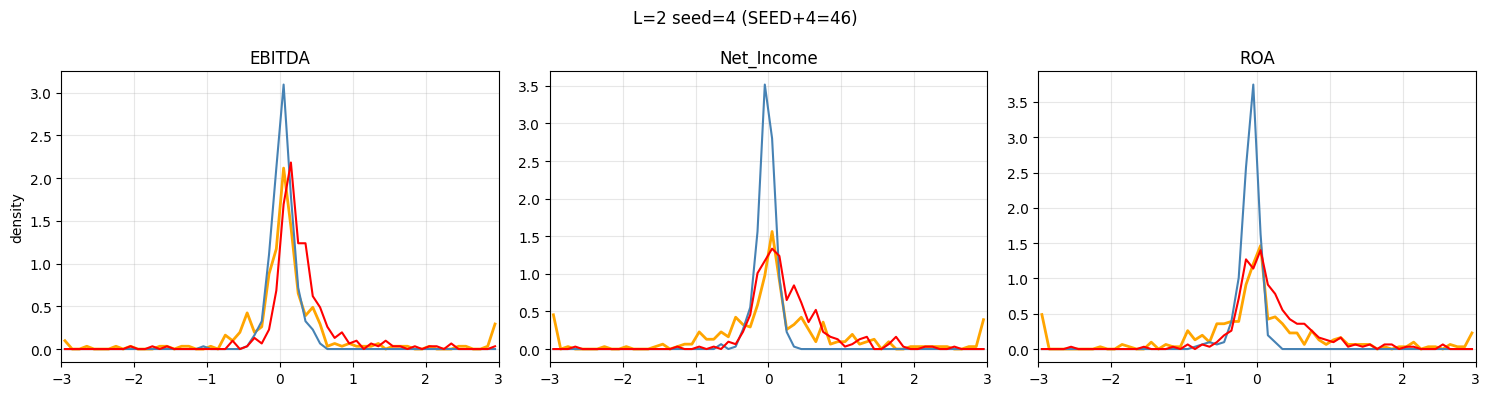

[L=3 seed=0] computed (n_test=307)


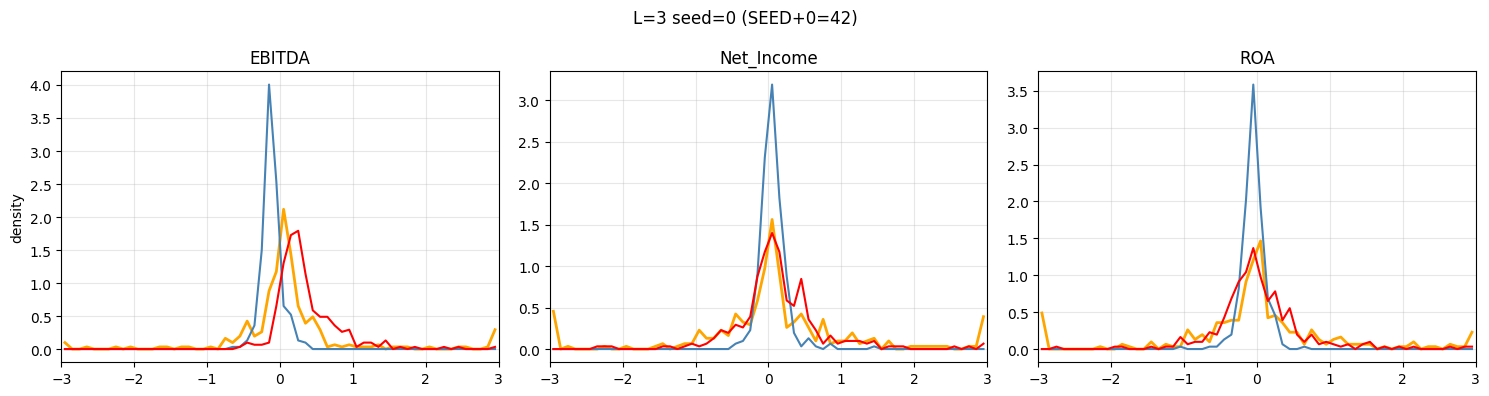

[L=3 seed=1] computed (n_test=307)


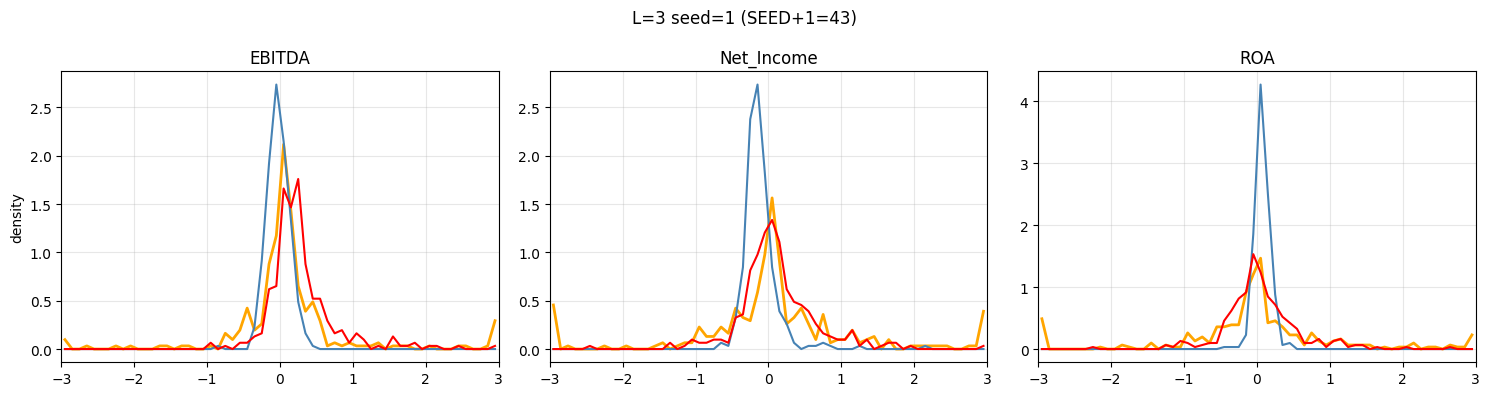

[L=3 seed=2] computed (n_test=307)


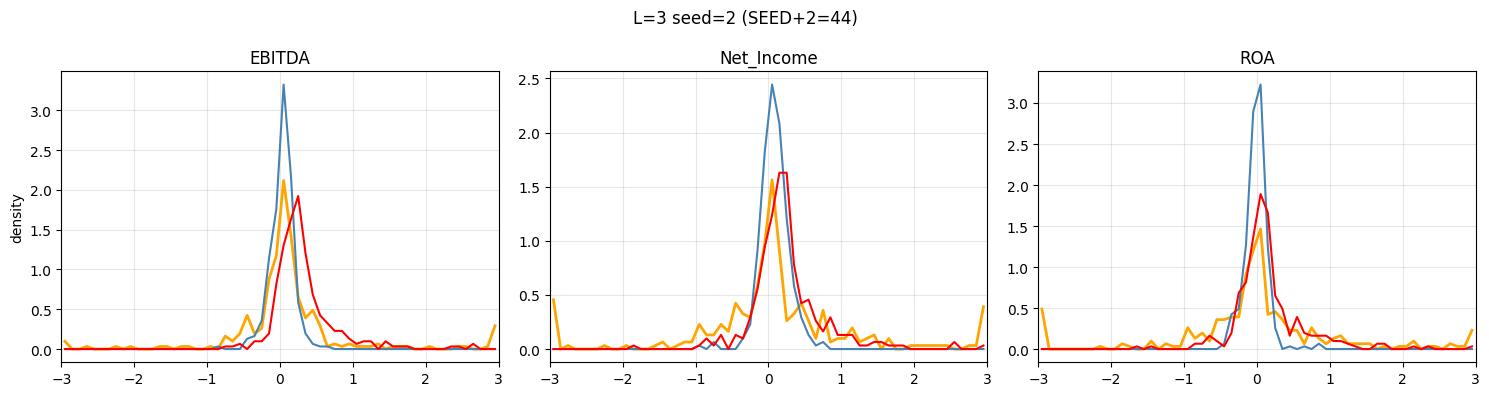

[L=3 seed=3] computed (n_test=307)


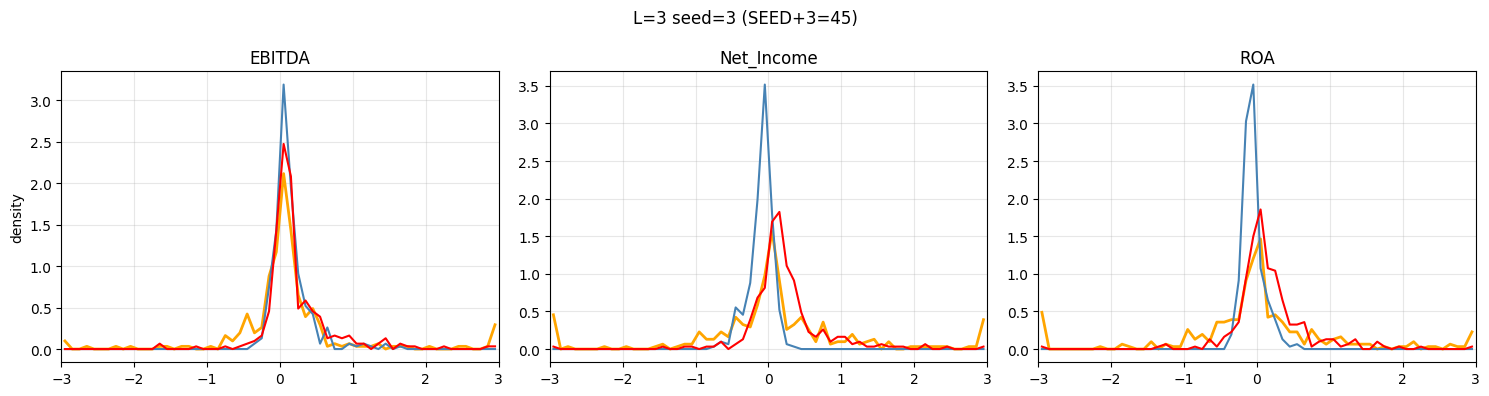

[L=3 seed=4] computed (n_test=307)


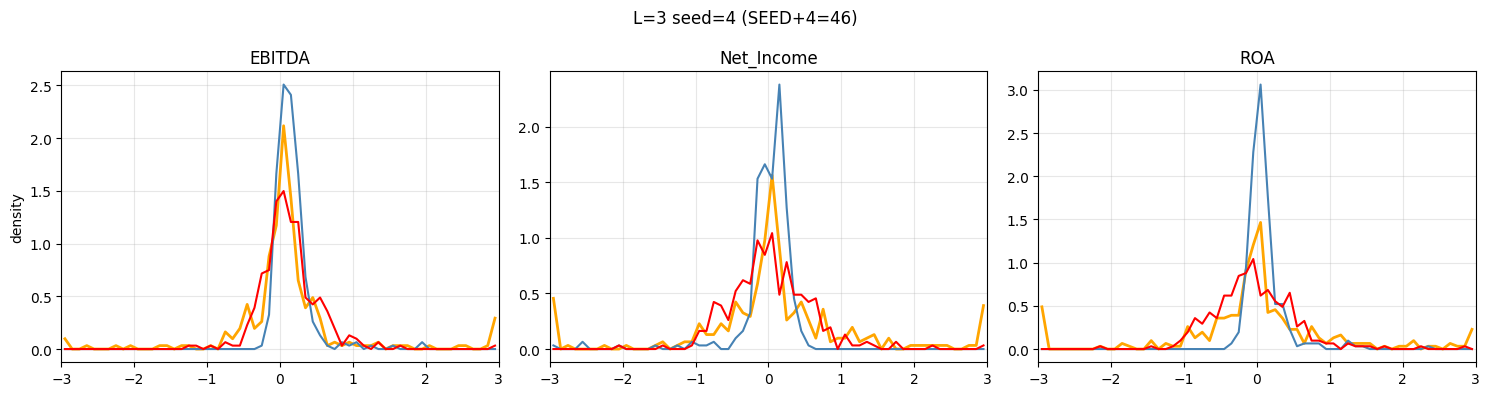

[L=4 seed=0] computed (n_test=307)


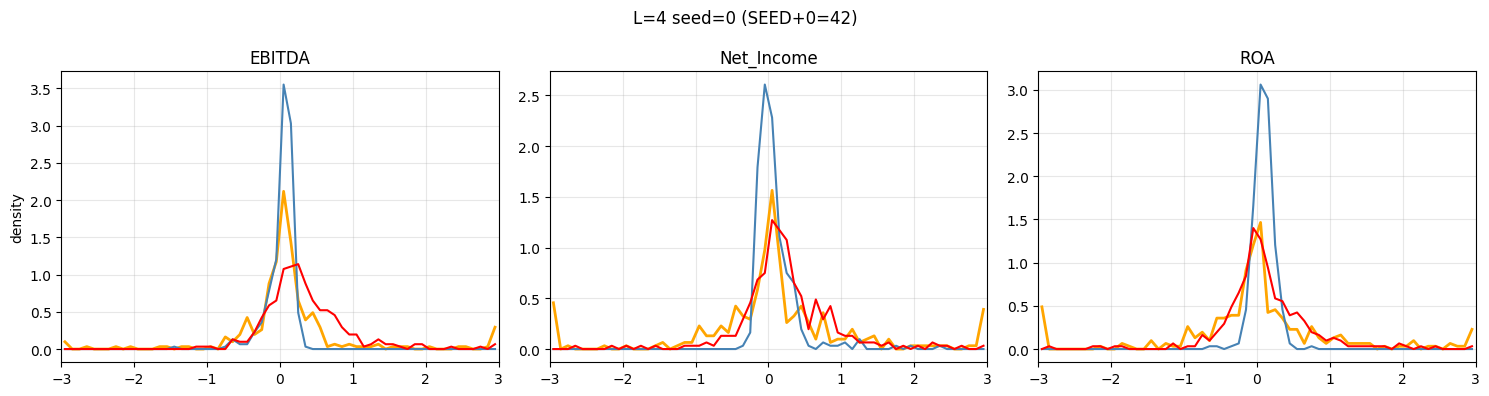

[L=4 seed=1] computed (n_test=307)


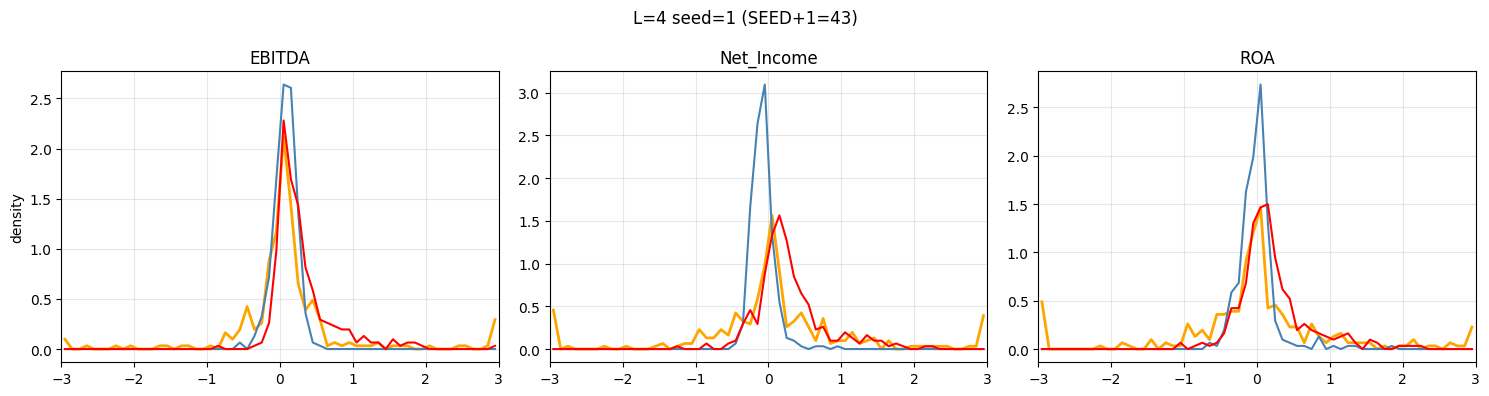

[L=4 seed=2] computed (n_test=307)


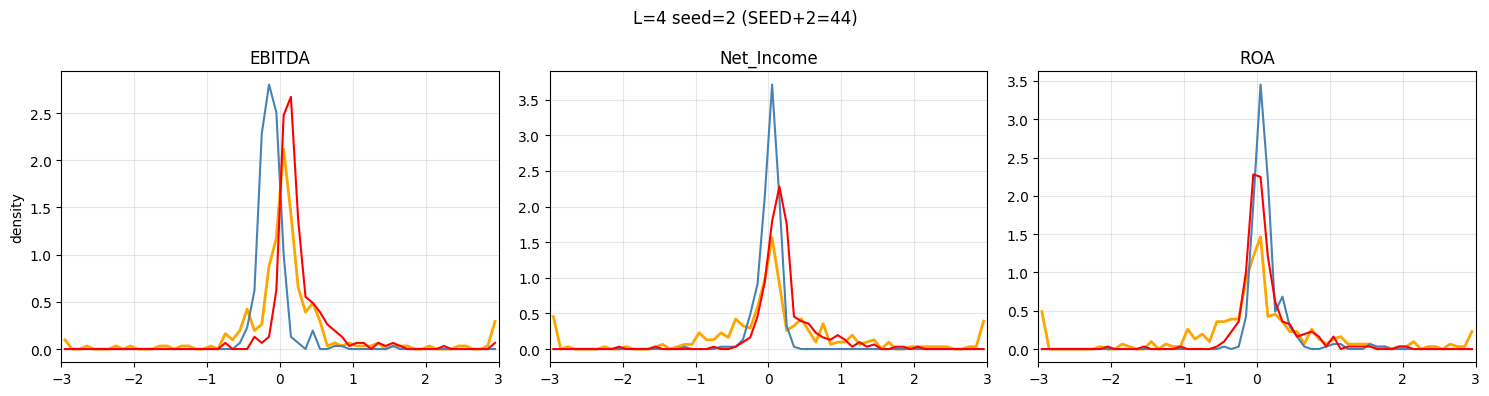

[L=4 seed=3] computed (n_test=307)


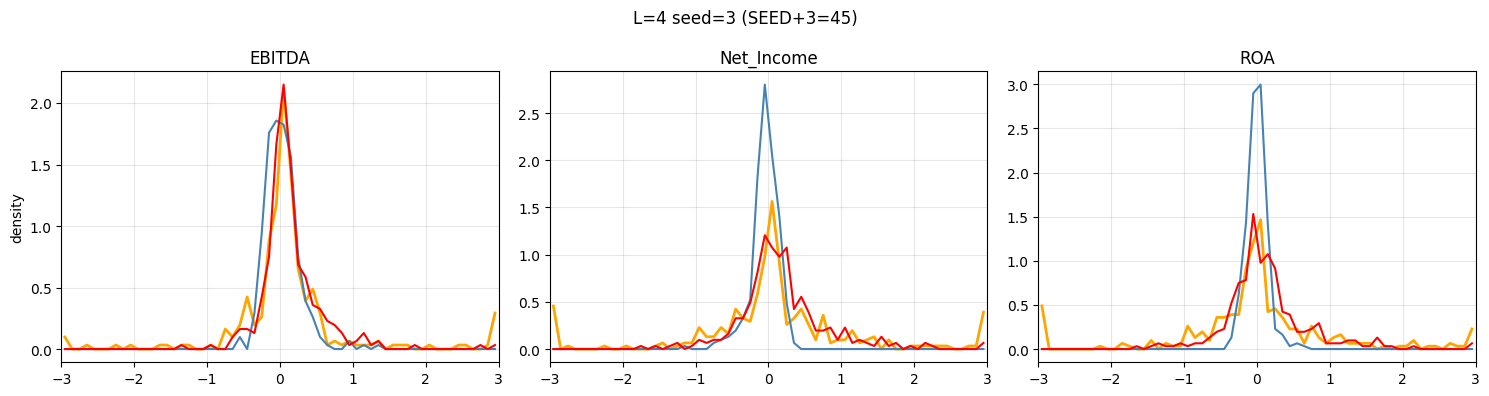

[L=4 seed=4] computed (n_test=307)


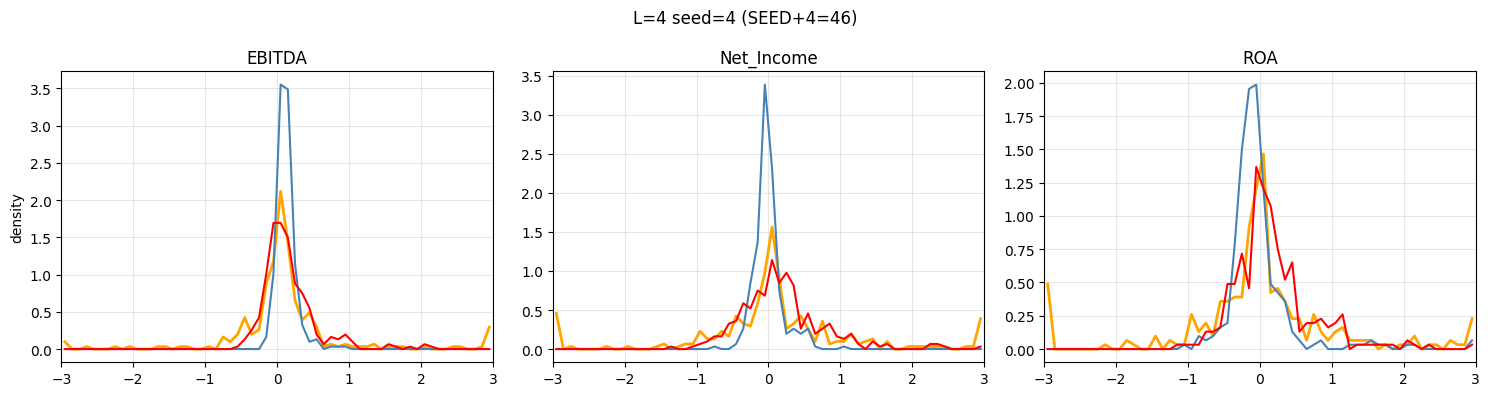

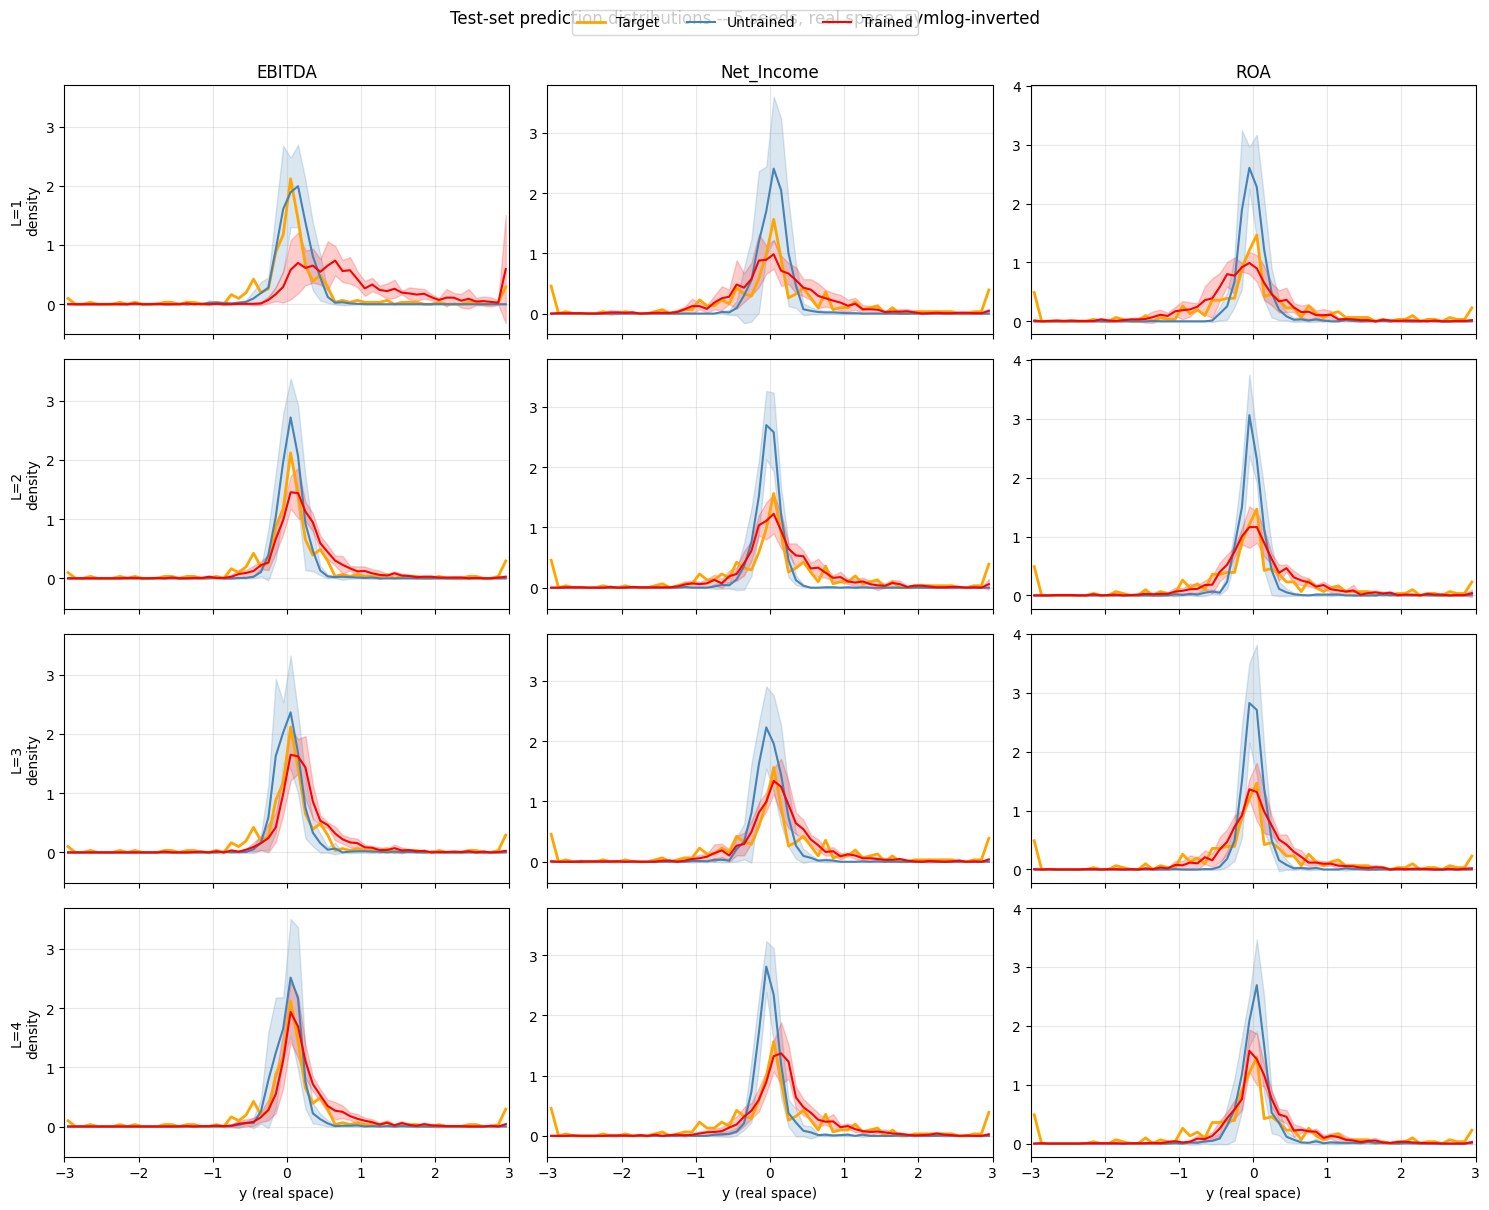


Summary across 5 seeds (real space, full test set):

Depth Target          mean|y| target    mean|yp| untrained    mean|yp| trained
--------------------------------------------------------------------------------
1     EBITDA                  0.4253                0.1876              0.9327
1     Net_Income              0.6960                0.1516              0.4696
1     ROA                     0.6632                0.1385              0.4540
2     EBITDA                  0.4253                0.1374              0.3592
2     Net_Income              0.6960                0.1277              0.4178
2     ROA                     0.6632                0.1369              0.4090
3     EBITDA                  0.4253                0.1500              0.3353
3     Net_Income              0.6960                0.1664              0.3793
3     ROA                     0.6632                0.1209              0.3552
4     EBITDA                  0.4253                0.1493              0.3

In [ ]:
def collect_predictions(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for bx, by, bmask, bstatic, lengths in loader:
            logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
            preds.append(logits.cpu().numpy())
            targets.append(by.numpy())
    yp = np.vstack(preds)
    yt = np.vstack(targets)
    yp_c = np.clip(yp, -SYMLOG_CAP, SYMLOG_CAP)
    yp_real = np.sign(yp_c) * np.expm1(np.abs(yp_c))
    yt_real = np.sign(yt) * np.expm1(np.abs(yt))
    return yp_real, yt_real

BIN_EDGES = np.linspace(-WINSOR_CAP, WINSOR_CAP, 61)
BIN_CENTERS = 0.5 * (BIN_EDGES[:-1] + BIN_EDGES[1:])

hist_target_per_L = {L: {t: None for t in PREDICTION_TARGETS} for L in DEPTHS}
hist_untrained_per_L = {L: {t: [] for t in PREDICTION_TARGETS} for L in DEPTHS}
hist_trained_per_L = {L: {t: [] for t in PREDICTION_TARGETS} for L in DEPTHS}
summary_stats = {L: {t: {} for t in PREDICTION_TARGETS} for L in DEPTHS}

for L in DEPTHS:
    for seed_idx in range(N_RUNS_DEPTH):
        cache_path = SAVE_DIR / f'distrib_L{L}_seed{seed_idx}.json'
        if cache_path.exists():
            with open(cache_path) as f:
                d = _json.load(f)
            yp_u = np.array(d['yp_u'])
            yp_t = np.array(d['yp_t'])
            yt = np.array(d['yt'])
            print(f"[L={L} seed={seed_idx}] loaded from disk (n_test={len(yt)})")
        else:
            seed = SEED + seed_idx
            set_seed(seed)
            model_u, _, _, test_loader = build_loaders_imp_depth(CONFIG, L)
            yp_u, yt = collect_predictions(model_u, test_loader)
            set_seed(seed)
            model_t, train_loader, val_loader, test_loader = build_loaders_imp_depth(CONFIG, L)
            opt = torch.optim.Adam(model_t.parameters(), lr=CONFIG['lr'], weight_decay=0.0)
            model_t, _ = train_with_diagnostics(
                model_t, train_loader, val_loader, opt,
                grad_clip=5.0, use_scheduler=False, max_epochs=MAX_EPOCHS, verbose=False
            )
            yp_t, yt = collect_predictions(model_t, test_loader)
            with open(cache_path, 'w') as f:
                _json.dump({'yp_u': yp_u.tolist(), 'yp_t': yp_t.tolist(),
                            'yt': yt.tolist(), 'L': L, 'seed': seed}, f)
            print(f"[L={L} seed={seed_idx}] computed (n_test={len(yt)})")

        fig_ps, axes_ps = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey='col')
        for col_ps, t_ps in enumerate(PREDICTION_TARGETS):
            ax_ps = axes_ps[col_ps]
            h_target_ps, _ = np.histogram(yt[:, col_ps], bins=BIN_EDGES, density=True)
            h_u_ps,      _ = np.histogram(yp_u[:, col_ps], bins=BIN_EDGES, density=True)
            h_t_ps,      _ = np.histogram(yp_t[:, col_ps], bins=BIN_EDGES, density=True)
            ax_ps.plot(BIN_CENTERS, h_target_ps, color='orange',   linewidth=2,   label='Target')
            ax_ps.plot(BIN_CENTERS, h_u_ps,      color='steelblue', linewidth=1.5, label='Untrained')
            ax_ps.plot(BIN_CENTERS, h_t_ps,      color='red',       linewidth=1.5, label='Trained')
            ax_ps.set_xlim(-WINSOR_CAP, WINSOR_CAP)
            ax_ps.grid(True, alpha=0.3)
            ax_ps.set_title(t_ps)
            if col_ps == 0:
                ax_ps.set_ylabel("density")
        fig_ps.suptitle(f"L={L} seed={seed_idx} (SEED+{seed_idx}={SEED + seed_idx})")
        plt.tight_layout()
        plt.savefig(SAVE_DIR / f'distrib_L{L}_seed{seed_idx}_progress.png', dpi=120, bbox_inches='tight')
        plt.show()
        for ti, t in enumerate(PREDICTION_TARGETS):
            yt_t = yt[:, ti]
            yp_u_t = yp_u[:, ti]
            yp_t_t = yp_t[:, ti]
            if hist_target_per_L[L][t] is None:
                h, _ = np.histogram(yt_t, bins=BIN_EDGES, density=True)
                hist_target_per_L[L][t] = h
            h_u, _ = np.histogram(yp_u_t, bins=BIN_EDGES, density=True)
            h_t, _ = np.histogram(yp_t_t, bins=BIN_EDGES, density=True)
            hist_untrained_per_L[L][t].append(h_u)
            hist_trained_per_L[L][t].append(h_t)
            for key, arr in [('target', yt_t), ('untrained', yp_u_t), ('trained', yp_t_t)]:
                summary_stats[L][t].setdefault(f'{key}_abs_mean', []).append(float(np.mean(np.abs(arr))))
            summary_stats[L][t].setdefault('untrained_frac_near_zero', []).append(float(np.mean(np.abs(yp_u_t) < 0.01)))
            summary_stats[L][t].setdefault('trained_frac_near_zero', []).append(float(np.mean(np.abs(yp_t_t) < 0.01)))

fig, axes = plt.subplots(len(DEPTHS), len(PREDICTION_TARGETS), figsize=(15, 12),
                         sharex=True, sharey='col')
for row, L in enumerate(DEPTHS):
    for col, t in enumerate(PREDICTION_TARGETS):
        ax = axes[row, col]
        ax.plot(BIN_CENTERS, hist_target_per_L[L][t], color='orange', linewidth=2, label='Target')
        h_u = np.stack(hist_untrained_per_L[L][t])
        mean_u, std_u = h_u.mean(0), h_u.std(0)
        ax.fill_between(BIN_CENTERS, mean_u - std_u, mean_u + std_u, color='steelblue', alpha=0.2)
        ax.plot(BIN_CENTERS, mean_u, color='steelblue', linewidth=1.5, label='Untrained')
        h_t = np.stack(hist_trained_per_L[L][t])
        mean_t, std_t = h_t.mean(0), h_t.std(0)
        ax.fill_between(BIN_CENTERS, mean_t - std_t, mean_t + std_t, color='red', alpha=0.2)
        ax.plot(BIN_CENTERS, mean_t, color='red', linewidth=1.5, label='Trained')
        ax.set_xlim(-WINSOR_CAP, WINSOR_CAP)
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(t)
        if col == 0:
            ax.set_ylabel(f"L={L}\ndensity")
        if row == len(DEPTHS) - 1:
            ax.set_xlabel("y (real space)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.01))
fig.suptitle("Test-set prediction distributions -- 5 seeds, real space, symlog-inverted", y=1.005)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'distrib_depths.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nSummary across 5 seeds (real space, full test set):\n")
print(f"{'Depth':<6}{'Target':<14}{'mean|y| target':>16}{'mean|yp| untrained':>22}{'mean|yp| trained':>20}")
print("-" * 80)
for L in DEPTHS:
    for t in PREDICTION_TARGETS:
        s = summary_stats[L][t]
        tm = np.mean(s['target_abs_mean'])
        um = np.mean(s['untrained_abs_mean'])
        trm = np.mean(s['trained_abs_mean'])
        print(f"{L:<6}{t:<14}{tm:>16.4f}{um:>22.4f}{trm:>20.4f}")
print()
print(f"{'Depth':<6}{'Target':<14}{'Frac |yp|<0.01 (untrained)':>32}{'Frac |yp|<0.01 (trained)':>30}")
print("-" * 84)
for L in DEPTHS:
    for t in PREDICTION_TARGETS:
        s = summary_stats[L][t]
        uf = np.mean(s['untrained_frac_near_zero'])
        tf = np.mean(s['trained_frac_near_zero'])
        print(f"{L:<6}{t:<14}{uf:>32.4f}{tf:>30.4f}")

# Sanity check vs section C's per-run cache
print("\nSanity check (this cell's test MAE vs section C's per-run cache):")
for L in DEPTHS:
    for seed_idx in range(N_RUNS_DEPTH):
        cache_path_c = SAVE_DIR / f'per_run_L{L}_seed{seed_idx}.json'
        cache_path_d = SAVE_DIR / f'distrib_L{L}_seed{seed_idx}.json'
        if cache_path_c.exists() and cache_path_d.exists():
            with open(cache_path_c) as f:
                dc = _json.load(f)
            with open(cache_path_d) as f:
                dd = _json.load(f)
            yp_u = np.array(dd['yp_u']); yp_t = np.array(dd['yp_t']); yt = np.array(dd['yt'])
            mask = ~np.isnan(yt)
            ae_u = float(np.abs(yp_u - yt)[mask].mean())
            ae_t = float(np.abs(yp_t - yt)[mask].mean())
            ok_u = abs(ae_u - dc['untrained']['Overall']) < 1e-4
            ok_t = abs(ae_t - dc['trained']['Overall']) < 1e-4
            print(f"  L={L} seed={seed_idx}: untrained OK={ok_u} (this={ae_u:.4f}, sec_C={dc['untrained']['Overall']:.4f}), "
                  f"trained OK={ok_t} (this={ae_t:.4f}, sec_C={dc['trained']['Overall']:.4f})")


## 4. Summary Tables & Visualizations

In [ ]:
per_run_rows = []
for L in DEPTHS:
    for run_idx in range(N_RUNS_DEPTH):
        per_run_path = SAVE_DIR / f'per_run_L{L}_seed{run_idx}.json'
        d = load_json(per_run_path)
        for t in PREDICTION_TARGETS + ['Overall']:
            per_run_rows.append({
                'depth': L, 'seed': d['seed'], 'target': t,
                'untrained':       d['untrained'].get(t),
                'trained':         d['trained'].get(t),
                'untrained_2024':  d['untrained_2024'].get(t),
                'trained_2024':    d['trained_2024'].get(t),
                'untrained_2025':  d['untrained_2025'].get(t),
                'trained_2025':    d['trained_2025'].get(t),
            })
df_per_run = pd.DataFrame(per_run_rows)
df_per_run.to_csv(SAVE_DIR / 'depth_sweep_per_run.csv', index=False)
print(f"Saved per-run CSV: {SAVE_DIR / 'depth_sweep_per_run.csv'}")

summary_rows = []
for L in DEPTHS:
    n_params = load_json(SAVE_DIR / f'capacity_L{L}.json')['n_params']
    for t in PREDICTION_TARGETS + ['Overall']:
        u   = np.array(depth_compare[L]['untrained'][t])
        tr  = np.array(depth_compare[L]['trained'][t])
        u24 = np.array(depth_compare[L]['untrained_2024'][t])
        tr24= np.array(depth_compare[L]['trained_2024'][t])
        u25 = np.array(depth_compare[L]['untrained_2025'][t])
        tr25= np.array(depth_compare[L]['trained_2025'][t])
        summary_rows.append({
            'depth': L, 'target': t, 'n_params': n_params,
            'untrained_mae':   float(u.mean()),   'untrained_std':   float(u.std()),
            'trained_mae':     float(tr.mean()),  'trained_std':     float(tr.std()),
            'delta':           float(tr.mean()  - u.mean()),
            'untrained_2024_mae': float(u24.mean()),
            'trained_2024_mae':   float(tr24.mean()),
            'delta_2024':         float(tr24.mean() - u24.mean()),
            'untrained_2025_mae': float(u25.mean()),
            'trained_2025_mae':   float(tr25.mean()),
            'delta_2025':         float(tr25.mean() - u25.mean()),
        })
df_summary = pd.DataFrame(summary_rows)
display(df_summary.round(4))


Saved per-run CSV: /content/sweep_results/depth_sweep_per_run.csv
Saved summary CSV: /content/sweep_results/depth_sweep_summary.csv

=== Depth Sweep Summary (real-space test MAE, μ ± σ, n=5) ===


,depth,target,n_params,untrained_mae,untrained_std,trained_mae,trained_std,delta,untrained_2024_mae,trained_2024_mae,delta_2024,untrained_2025_mae,trained_2025_mae,delta_2025
0,1,EBITDA,80325,0.4826,0.0225,0.9840,0.4208,0.5013,0.5134,0.8439,0.3305,0.4505,1.1296,0.6790
1,1,Net_Income,80325,0.7258,0.0155,0.8360,0.0303,0.1102,0.7194,0.8576,0.1381,0.7324,0.8134,0.0810
2,1,ROA,80325,0.6867,0.0064,0.8140,0.0564,0.1273,0.7007,0.8624,0.1617,0.6721,0.7637,0.0916
3,1,Overall,80325,0.6318,0.0134,0.8779,0.1416,0.2461,0.6447,0.8546,0.2100,0.6184,0.9022,0.2839
4,2,EBITDA,212421,0.4523,0.0171,0.5261,0.0449,0.0737,0.5032,0.5569,0.0537,0.3994,0.4940,0.0946
5,2,Net_Income,212421,0.7236,0.0147,0.8132,0.0680,0.0896,0.7180,0.8296,0.1116,0.7294,0.7959,0.0666
6,2,ROA,212421,0.7039,0.0132,0.7852,0.0583,0.0813,0.7089,0.8099,0.1010,0.6987,0.7595,0.0608
7,2,Overall,212421,0.6267,0.0093,0.7083,0.0492,0.0816,0.6435,0.7323,0.0888,0.6092,0.6831,0.0740
8,3,EBITDA,344517,0.4449,0.0284,0.5046,0.0175,0.0597,0.4939,0.5578,0.0639,0.3939,0.4492,0.0553
9,3,Net_Income,344517,0.7371,0.0242,0.7814,0.0364,0.0443,0.7393,0.8130,0.0737,0.7348,0.7483,0.0135


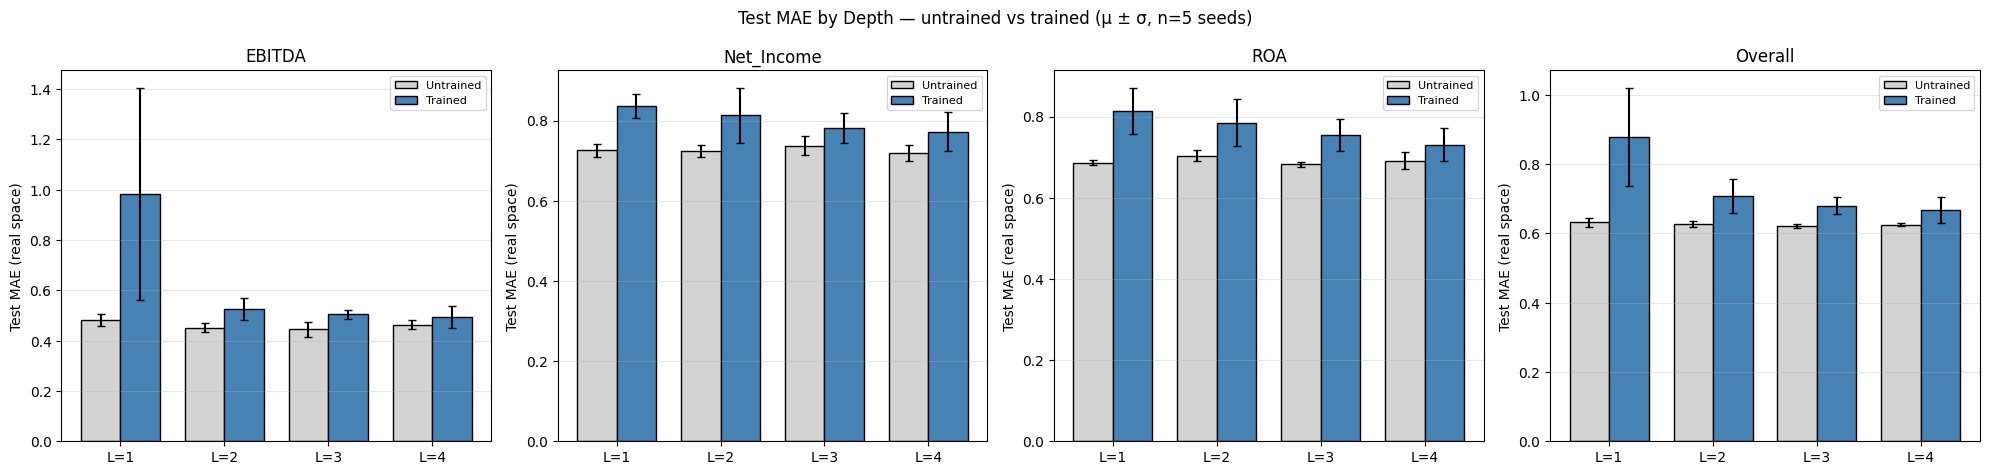

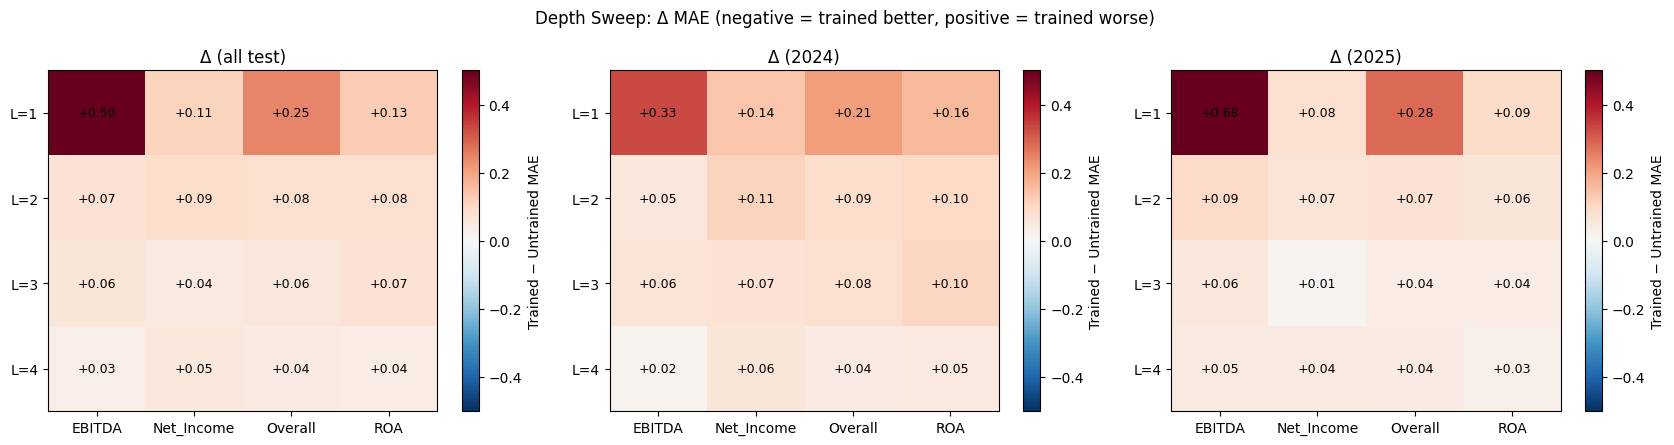


=== Verdict (best depth per target) ===
  EBITDA      : best depth = L=4 (MAE = 0.4959 ± 0.0440)
  Net_Income  : best depth = L=4 (MAE = 0.7723 ± 0.0485)
  ROA         : best depth = L=4 (MAE = 0.7308 ± 0.0403)
  Overall     : best depth = L=4 (MAE = 0.6664 ± 0.0373)

=== Verdict (best depth per target on 2024) ===
  EBITDA      : best depth = L=4 (2024 MAE = 0.5311)
  Net_Income  : best depth = L=4 (2024 MAE = 0.7786)
  ROA         : best depth = L=4 (2024 MAE = 0.7526)
  Overall     : best depth = L=4 (2024 MAE = 0.6876)

=== Verdict (best depth per target on 2025) ===
  EBITDA      : best depth = L=3 (2025 MAE = 0.4492)
  Net_Income  : best depth = L=3 (2025 MAE = 0.7483)
  ROA         : best depth = L=4 (2025 MAE = 0.7081)
  Overall     : best depth = L=3 (2025 MAE = 0.6360)


In [ ]:
targets_show = PREDICTION_TARGETS + ['Overall']
fig, axes = plt.subplots(1, len(targets_show), figsize=(5*len(targets_show), 4.8), sharey=False)
x = np.arange(len(DEPTHS))
width = 0.38
for ax, t in zip(axes, targets_show):
    sub = df_summary[df_summary['target'] == t].set_index('depth')
    u_means = [sub.loc[L, 'untrained_mae'] for L in DEPTHS]
    u_stds  = [sub.loc[L, 'untrained_std']  for L in DEPTHS]
    t_means = [sub.loc[L, 'trained_mae']    for L in DEPTHS]
    t_stds  = [sub.loc[L, 'trained_std']    for L in DEPTHS]
    ax.bar(x - width/2, u_means, width, yerr=u_stds, capsize=3,
           label='Untrained', color='lightgray', edgecolor='black')
    ax.bar(x + width/2, t_means, width, yerr=t_stds, capsize=3,
           label='Trained',   color='steelblue', edgecolor='black')
    ax.set_xticks(x); ax.set_xticklabels([f'L={L}' for L in DEPTHS])
    ax.set_title(f'{t}'); ax.set_ylabel('Test MAE (real space)'); ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=8)
fig.suptitle(f"Test MAE by Depth — untrained vs trained ({N_RUNS_DEPTH} seeds)")
plt.tight_layout()
plt.savefig(SAVE_DIR / 'summary_bars.png', dpi=120, bbox_inches='tight')
plt.show()

# --- Heatmap of Δ = trained - untrained per (depth, target) ---
delta_pivot       = df_summary.pivot(index='depth', columns='target', values='delta')
delta_2024_pivot  = df_summary.pivot(index='depth', columns='target', values='delta_2024')
delta_2025_pivot  = df_summary.pivot(index='depth', columns='target', values='delta_2025')
vmax = max(abs(delta_pivot.values.max()), abs(delta_pivot.values.min()), 0.5)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, pivot, title in zip(axes,
        [delta_pivot, delta_2024_pivot, delta_2025_pivot],
        ['Δ (all test)', 'Δ (2024)', 'Δ (2025)']):
    im = ax.imshow(pivot.values, cmap='RdBu_r', aspect='auto',
                   vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels([f'L={L}' for L in pivot.index])
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i,j]:+.2f}",
                    ha='center', va='center', fontsize=9, color='black')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='Trained − Untrained MAE')
fig.suptitle("Depth Sweep: Δ MAE (negative = trained better, positive = trained worse)")
plt.tight_layout()
plt.savefig(SAVE_DIR / 'summary_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# --- Verdict ---
print("\n=== Verdict (best depth per target) ===")
for t in targets_show:
    sub = df_summary[df_summary['target'] == t].set_index('depth')
    best_L = sub['trained_mae'].idxmin()
    print(f"  {t:12s}: best depth = L={best_L} "
          f"(MAE = {sub.loc[best_L, 'trained_mae']:.4f} ± {sub.loc[best_L, 'trained_std']:.4f})")
print("\n=== Verdict (best depth per target on 2024) ===")
for t in targets_show:
    sub = df_summary[df_summary['target'] == t].set_index('depth')
    best_L = sub['trained_2024_mae'].idxmin()
    print(f"  {t:12s}: best depth = L={best_L} "
          f"(2024 MAE = {sub.loc[best_L, 'trained_2024_mae']:.4f})")
print("\n=== Verdict (best depth per target on 2025) ===")
for t in targets_show:
    sub = df_summary[df_summary['target'] == t].set_index('depth')
    best_L = sub['trained_2025_mae'].idxmin()
    print(f"  {t:12s}: best depth = L={best_L} "
          f"(2025 MAE = {sub.loc[best_L, 'trained_2025_mae']:.4f})")
